# Linear Attention ViT Pipeline for Particle Collision Images

**GSoC ML4SCI Project** -- Project-Requirement Aligned Notebook

This notebook is aligned to the required task flow:
1. **Pretrain Linear Attention ViT encoder** on unlabeled detector images using three SSL methods: **SimMIM, MAE, MAEv2**
2. **Save separate pretrained encoder weights** for each SSL method
3. **Fine-tune Linear Attention ViT** (low learning rate) from each pretrained encoder on labeled data
4. **Train the same Linear Attention ViT from scratch** under matched settings
5. **Compare SimMIM/MAE/MAEv2-pretrained vs scratch** using classification + regression metrics

Primary architecture for the required path:
- **Linear Attention ViT** -- ReLU/positive-kernel linear attention, O(N*d^2) in tokens

Secondary baselines (optional for broader benchmarking):
- Standard ViT, L2ViT, XCiT ViT

Architecture diagrams: `../images/`

---

### Changelog (Alignment + Stability)

| Change | Why |
|--------|-----|
| Requirement-first narrative (pretrain -> fine-tune -> scratch) | Matches project/mentor task description exactly |
| Linear-attention modular SSL classes in Section 5 | Keeps architecture and SSL implementation consistent |
| NaN-safe attention/loss guards | Prevents unstable pretraining loss explosions in notebook runs |
| Backward-compatible class aliases (`*Pretrainer`) | Keeps existing training/eval code unchanged |
| Existing loops/data/eval left untouched | Preserves reproducibility of your original workflow |

**How to run:**
- **Quick sanity test:** Set `RUN_MODE = "debug"` in Section 1, then Run All.
- **Full required experiment:** Set `RUN_MODE = "full"`, run Section 9 -> Section 10 -> Section 11.
- **Reporting:** Use benchmark and summary sections to compare SimMIM/MAE/MAEv2-pretrained vs scratch and baselines.

## Section 1: Configuration

In [20]:
# ============================================================
# Section 1: Configuration
# All hyperparameters in one place for reproducibility
# ============================================================
#
# --- v2 changes ---
# • Added STRICT_DETERMINISM toggle (default False)
# • Added RUN_MODE ("debug" / "full") for quick sanity vs full run
# • Added USE_AMP, USE_EMA toggles (both default False for notebook stability)
# • Added LAMBDA_REG, USE_HUBER_LOSS, TWO_PHASE_TRAINING config
# • DataLoader defaults: num_workers=0, pin_memory=False
# ============================================================

import os
import random
import time
import warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn

warnings.filterwarnings("ignore")

# ----------------------------------------------------------
# Run mode: "full" (production training) or "debug" (2 epochs, fast sanity check)
# ----------------------------------------------------------
RUN_MODE = "full"

# ----------------------------------------------------------
# Determinism control
# ----------------------------------------------------------
# STRICT_DETERMINISM = True requires:
#   - Setting env var CUBLAS_WORKSPACE_CONFIG=:4096:8 BEFORE launching Python
#   - A kernel restart after changing this flag
# Default False avoids CUBLAS workspace errors on Windows / Jupyter.
STRICT_DETERMINISM = False

# ----------------------------------------------------------
# Hyperparameters
# ----------------------------------------------------------

# Model
IMG_SIZE = 64          # Input image resolution
PATCH_SIZE = 8         # Patch size for tokenization
IN_CHANS = 8           # Number of input channels (detector layers)
EMBED_DIM = 256        # Transformer embedding dimension
DEPTH = 10             # Number of transformer blocks
NUM_HEADS = 8          # Number of attention heads
MLP_RATIO = 4.0        # MLP hidden dim ratio
DROPOUT = 0.1          # Dropout probability

# Training
BATCH_SIZE = 32
EPOCHS = 35
LR = 3e-4
WEIGHT_DECAY = 1e-4
TRAIN_FRAC = 0.80      # 80/20 train/val split
SEED = 42
LAMBDA_REG = 0.2       # Weight for regression loss (was 1.0; 0.2 focuses on classification)
REGRESSION_LAMBDA = LAMBDA_REG  # backward compat alias
GRAD_CLIP_NORM = 1.0   # Max gradient norm for clipping

# Loss options
USE_HUBER_LOSS = False  # True = SmoothL1 (Huber) for mass regression; False = MSE

# AMP & EMA
USE_AMP = False         # Set True for GPU speed-up (may cause dtype issues in notebook)
USE_EMA = False         # Exponential Moving Average of model weights

# Early stopping
ES_PATIENCE = 7         # Patience for early stopping on val macro-F1

# Two-phase training (OFF by default)
TWO_PHASE_TRAINING = False
PHASE_A_EPOCHS = 5      # classification-focused warmup epochs (lambda_reg ≈ 0)
PHASE_A_LAMBDA = 0.0    # regression weight during Phase A

# Logging
LOG_EVERY_N_BATCHES = 50  # Print batch progress every N batches (0 = off)

# Pretraining
PRETRAIN_EPOCHS = 20
MASK_RATIO = 0.50
LR_PRETRAIN = 1e-3

# Data paths
DATA_DIR = Path(r"C:\Users\Rahul\Desktop\AA Gsoc'26\data")
UNLABELED_FILE = DATA_DIR / "Dataset_Specific_Unlabelled.h5"
LABELED_FILE = DATA_DIR / "Dataset_Specific_labelled_full_only_for_2i.h5"

NUM_CLASSES = 2  # quark vs gluon (or whatever the dataset has)

# ----------------------------------------------------------
# DataLoader defaults (stability in Jupyter / Windows)
# ----------------------------------------------------------
DL_NUM_WORKERS = 0
DL_PIN_MEMORY = False

# ----------------------------------------------------------
# Multi-seed runner seeds (optional robustness section)
# ----------------------------------------------------------
MULTI_SEEDS = [42, 52, 62]

# ----------------------------------------------------------
# Device detection
# ----------------------------------------------------------

def get_device() -> torch.device:
    """Auto-detect the best available compute device."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = get_device()
print(f"Using device: {DEVICE}", flush=True)
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}", flush=True)
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB", flush=True)


# ----------------------------------------------------------
# Reproducibility — seed everything
# ----------------------------------------------------------

def seed_everything(seed: int = 42) -> None:
    """Set all random seeds for full reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if STRICT_DETERMINISM:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.use_deterministic_algorithms(True)
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True
        torch.use_deterministic_algorithms(False)


seed_everything(SEED)
print(f"Seeds set to {SEED} | STRICT_DETERMINISM={STRICT_DETERMINISM}", flush=True)
print(f"RUN_MODE={RUN_MODE} | EPOCHS={EPOCHS} | PRETRAIN_EPOCHS={PRETRAIN_EPOCHS}", flush=True)
print(f"BATCH_SIZE={BATCH_SIZE} | LR={LR} | WEIGHT_DECAY={WEIGHT_DECAY}", flush=True)
print(f"LAMBDA_REG={LAMBDA_REG} | USE_AMP={USE_AMP} | USE_EMA={USE_EMA}", flush=True)
print(f"PyTorch version: {torch.__version__}", flush=True)

# ----------------------------------------------------------
# Optional debug override (uncomment ONLY for quick sanity checks)
# ----------------------------------------------------------
# RUN_MODE = "debug"
# EPOCHS = 2
# PRETRAIN_EPOCHS = 2


Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
GPU Memory: 6.4 GB
Seeds set to 42 | STRICT_DETERMINISM=False
RUN_MODE=full | EPOCHS=35 | PRETRAIN_EPOCHS=20
BATCH_SIZE=32 | LR=0.0003 | WEIGHT_DECAY=0.0001
LAMBDA_REG=0.2 | USE_AMP=False | USE_EMA=False
PyTorch version: 2.3.0+cu121


## Section 2: Dataset Loading

In [21]:
# ============================================================
# Section 2: Dataset Loading (HDF5 ONLY, no synthetic fallback)
# ============================================================

import h5py
import numpy as np
import torch
from torch.utils.data import Dataset


def inspect_hdf5(filepath: str) -> None:
    """Print HDF5 structure, shapes, dtypes, and sample unique values for 1D datasets."""
    print(f"\n=== HDF5 File: {filepath} ===")
    with h5py.File(filepath, "r") as f:
        def _print_tree(name, obj):
            indent = "  " * name.count("/")
            if hasattr(obj, "shape"):
                msg = f"{indent}{name}: shape={obj.shape}, dtype={obj.dtype}"
                if len(obj.shape) == 1 and obj.shape[0] > 0:
                    sample = np.asarray(obj[: min(50, obj.shape[0])]).reshape(-1)
                    msg += f", sample_unique={np.unique(sample)}"
                print(msg)
            else:
                print(f"{indent}{name}/")
        f.visititems(_print_tree)


class LazyHDF5Dataset(Dataset):
    """
    Lazy-loading HDF5 dataset for particle collision images.
    Requires valid keys for labeled data (mass + label).
    """

    def __init__(
        self,
        filepath,
        labeled: bool = True,
        transform=None,
        img_key: str = None,
        mass_key: str = None,
        label_key: str = None,
    ):
        self.filepath = str(filepath)
        self.labeled = labeled
        self.transform = transform
        self._file = None  # lazy handle

        with h5py.File(self.filepath, "r") as f:
            keys = list(f.keys())

            # -----------------------
            # Resolve image key
            # -----------------------
            if img_key is not None:
                if img_key not in keys:
                    raise ValueError(f"img_key='{img_key}' not found. Available keys: {keys}")
                self.img_key = img_key
            else:
                preferred_img = ["jet", "X", "images", "image", "data", "X_jets", "jet_images", "jets"]
                self.img_key = None
                for k in preferred_img:
                    if k in keys and hasattr(f[k], "shape") and len(f[k].shape) >= 3:
                        self.img_key = k
                        break
                if self.img_key is None:
                    for k in keys:
                        obj = f[k]
                        if hasattr(obj, "shape") and len(obj.shape) >= 3 and obj.shape[0] > 1:
                            self.img_key = k
                            break
                if self.img_key is None:
                    raise ValueError(f"No image-like key found in {self.filepath}. Keys={keys}")

            self.length = int(f[self.img_key].shape[0])

            # -----------------------
            # Resolve labeled keys
            # -----------------------
            self.mass_key = None
            self.label_key = None

            if self.labeled:
                # mass key
                if mass_key is not None:
                    if mass_key not in keys:
                        raise ValueError(f"mass_key='{mass_key}' not found. Available keys: {keys}")
                    self.mass_key = mass_key
                else:
                    for k in ["m", "mass", "m0", "y_mass", "target_mass"]:
                        if k in keys and len(f[k].shape) == 1 and f[k].shape[0] == self.length:
                            self.mass_key = k
                            break
                    if self.mass_key is None:
                        raise ValueError(
                            f"Could not infer mass_key. Please pass it explicitly. Available keys: {keys}"
                        )

                # label key
                if label_key is not None:
                    if label_key not in keys:
                        raise ValueError(f"label_key='{label_key}' not found. Available keys: {keys}")
                    self.label_key = label_key
                else:
                    for k in ["label", "labels", "y", "cls", "class", "target", "pid"]:
                        if k in keys and len(f[k].shape) == 1 and f[k].shape[0] == self.length:
                            self.label_key = k
                            break
                    if self.label_key is None:
                        # fallback: integer-like 1D key with matching length (excluding mass)
                        for k in keys:
                            if k == self.mass_key:
                                continue
                            obj = f[k]
                            if hasattr(obj, "shape") and len(obj.shape) == 1 and obj.shape[0] == self.length:
                                if np.issubdtype(obj.dtype, np.integer):
                                    self.label_key = k
                                    break

                    if self.label_key is None:
                        raise ValueError(
                            f"Could not infer label_key. Please pass it explicitly. Available keys: {keys}"
                        )

        print(f"[LazyHDF5Dataset] file={self.filepath}")
        print(f"  img_key={self.img_key}")
        if self.labeled:
            print(f"  mass_key={self.mass_key}, label_key={self.label_key}")

    def _get_file(self):
        if self._file is None or not self._file.id.valid:
            self._file = h5py.File(self.filepath, "r")
        return self._file

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        f = self._get_file()

        img = np.array(f[self.img_key][idx], dtype=np.float32)
        img = torch.from_numpy(img)

        # Normalize to CHW
        if img.ndim == 2:
            img = img.unsqueeze(0)  # (1,H,W)
        elif img.ndim == 3:
            # HWC -> CHW if last dim looks like channels
            if img.shape[-1] <= 16 and img.shape[0] > 16 and img.shape[1] > 16:
                img = img.permute(2, 0, 1)

        if self.transform is not None:
            img = self.transform(img)

        if self.labeled:
            mass = float(f[self.mass_key][idx])
            label = int(f[self.label_key][idx])
            return img, torch.tensor(mass, dtype=torch.float32), torch.tensor(label, dtype=torch.long)
        else:
            return (img,)

    def __del__(self):
        if self._file is not None and self._file.id.valid:
            self._file.close()


# ----------------------------------------------------------
# Strictly require HDF5 files (no synthetic fallback)
# ----------------------------------------------------------

print("\n--- Loading Datasets (HDF5 only) ---")

if not LABELED_FILE.exists():
    raise FileNotFoundError(f"Labeled HDF5 file not found: {LABELED_FILE}")
if not UNLABELED_FILE.exists():
    raise FileNotFoundError(f"Unlabeled HDF5 file not found: {UNLABELED_FILE}")

print(f"Found labeled file: {LABELED_FILE}")
inspect_hdf5(str(LABELED_FILE))

print(f"\nFound unlabeled file: {UNLABELED_FILE}")
inspect_hdf5(str(UNLABELED_FILE))

# IMPORTANT: set these to your actual keys from inspect_hdf5 output
LABELED_IMG_KEY = "jet"
LABELED_MASS_KEY = "m"
LABELED_LABEL_KEY = "Y"
UNLABELED_IMG_KEY = "jet"

raw_dataset = LazyHDF5Dataset(
    LABELED_FILE,
    labeled=True,
    img_key=LABELED_IMG_KEY,
    mass_key=LABELED_MASS_KEY,
    label_key=LABELED_LABEL_KEY,
)
unlabeled_dataset_raw = LazyHDF5Dataset(
    UNLABELED_FILE,
    labeled=False,
    img_key=UNLABELED_IMG_KEY,
)

print(f"\nLabeled dataset size: {len(raw_dataset)}")
print(f"Unlabeled dataset size: {len(unlabeled_dataset_raw)}")
print("USING_SYNTHETIC = False")
USING_SYNTHETIC = False


--- Loading Datasets (HDF5 only) ---
Found labeled file: C:\Users\Rahul\Desktop\AA Gsoc'26\data\Dataset_Specific_labelled_full_only_for_2i.h5

=== HDF5 File: C:\Users\Rahul\Desktop\AA Gsoc'26\data\Dataset_Specific_labelled_full_only_for_2i.h5 ===
Y: shape=(10000, 1), dtype=float32
jet: shape=(10000, 125, 125, 8), dtype=float32
m: shape=(10000, 1), dtype=float32
pT: shape=(10000, 1), dtype=float32

Found unlabeled file: C:\Users\Rahul\Desktop\AA Gsoc'26\data\Dataset_Specific_Unlabelled.h5

=== HDF5 File: C:\Users\Rahul\Desktop\AA Gsoc'26\data\Dataset_Specific_Unlabelled.h5 ===
jet: shape=(60000, 125, 125, 8), dtype=float32
[LazyHDF5Dataset] file=C:\Users\Rahul\Desktop\AA Gsoc'26\data\Dataset_Specific_labelled_full_only_for_2i.h5
  img_key=jet
  mass_key=m, label_key=Y
[LazyHDF5Dataset] file=C:\Users\Rahul\Desktop\AA Gsoc'26\data\Dataset_Specific_Unlabelled.h5
  img_key=jet

Labeled dataset size: 10000
Unlabeled dataset size: 60000
USING_SYNTHETIC = False


## Section 3: Data Preprocessing & Augmentation

Train samples: 8000 | Val samples: 2000
Label distribution (full):  Counter({0: 5122, 1: 4878})
Label distribution (train): Counter({0: 4107, 1: 3893})
Label distribution (val):   Counter({0: 1015, 1: 985})
Mass normalization: mean=142.4647, std=50.5794
Train batches: 250 | Val batches: 63

--- Unlabeled samples (log-compressed, ch 0) ---


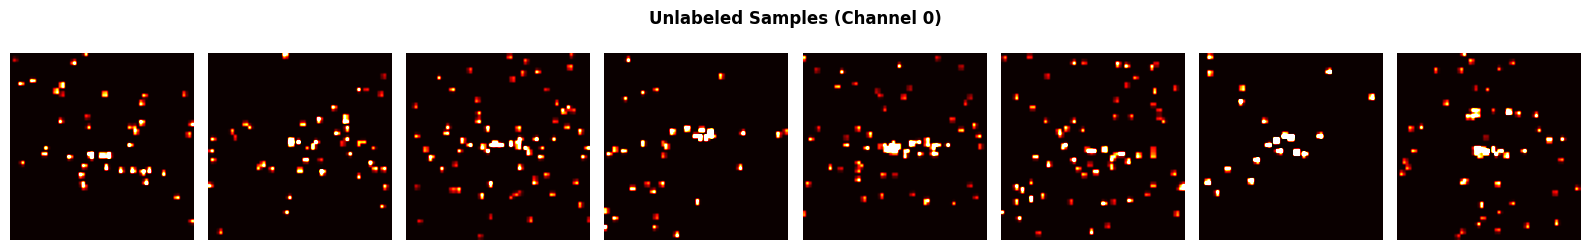


--- Labeled validation samples (log-compressed, ch 0) ---


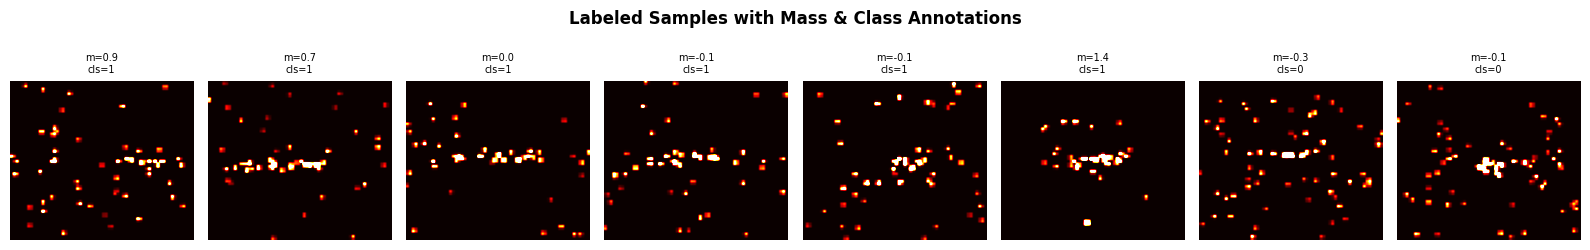

In [22]:
# ============================================================
# Section 3: Data Preprocessing & Augmentation (IMPROVED)
# - Energy centroid alignment
# - Safer physics-aware augmentation
# - Per-channel normalization
# - Safer mass normalization (explicit args)
# ============================================================

import math
import random
import warnings
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt


# ============================================================
# Physics Preprocessing
# ============================================================

class PhysicsPreprocess(nn.Module):
    """Physics-inspired preprocessing for detector images."""

    def __init__(self, img_size: int = 64, in_chans: int = 8, allow_fallback_zeros: bool = True):
        super().__init__()
        self.img_size = int(img_size)
        self.in_chans = int(in_chans)
        self.allow_fallback_zeros = allow_fallback_zeros

        y_coords, x_coords = torch.meshgrid(
            torch.arange(self.img_size, dtype=torch.float32),
            torch.arange(self.img_size, dtype=torch.float32),
            indexing="ij",
        )
        self.register_buffer("x_coords", x_coords, persistent=False)
        self.register_buffer("y_coords", y_coords, persistent=False)

    def _fallback_image(self, device, dtype):
        return torch.zeros((self.in_chans, self.img_size, self.img_size), device=device, dtype=dtype)

    def _to_chw(self, x: torch.Tensor) -> torch.Tensor:
        if not torch.is_tensor(x):
            x = torch.as_tensor(x)
        x = x.float()

        if x.ndim == 0:
            if self.allow_fallback_zeros:
                warnings.warn("PhysicsPreprocess: scalar input encountered; using zeros fallback.")
                return self._fallback_image(x.device, x.dtype)
            raise ValueError(f"Expected image-like tensor, got scalar: {x}")

        if x.ndim == 1 and x.numel() <= 1:
            if self.allow_fallback_zeros:
                warnings.warn(f"PhysicsPreprocess: tiny 1D input shape={tuple(x.shape)}; using zeros fallback.")
                return self._fallback_image(x.device, x.dtype)
            raise ValueError(f"Tiny 1D tensor cannot represent image: shape={tuple(x.shape)}")

        if x.ndim == 1:
            n = x.numel()
            if n % self.in_chans == 0:
                hw = n // self.in_chans
                h = int(math.isqrt(hw))
                if h * h == hw:
                    return x.view(self.in_chans, h, h)
            h = int(math.isqrt(n))
            if h * h == n:
                return x.view(1, h, h)
            if self.allow_fallback_zeros:
                warnings.warn(f"PhysicsPreprocess: cannot infer image shape from flattened length={n}; fallback zeros.")
                return self._fallback_image(x.device, x.dtype)
            raise ValueError(f"Cannot infer image shape from flattened tensor length={n}")

        if x.ndim == 2:
            return x.unsqueeze(0)

        if x.ndim == 3:
            if x.shape[-1] <= 16 and x.shape[0] > 16 and x.shape[1] > 16:
                return x.permute(2, 0, 1)
            return x

        if self.allow_fallback_zeros:
            warnings.warn(f"PhysicsPreprocess: unsupported ndim={x.ndim}, shape={tuple(x.shape)}; fallback zeros.")
            return self._fallback_image(x.device, x.dtype)
        raise ValueError(f"Unsupported input shape: {tuple(x.shape)}")

    def energy_center_align(self, x: torch.Tensor) -> torch.Tensor:
        c, h, w = x.shape

        energy = x.sum(dim=0)
        total_energy = energy.sum()
        if total_energy.abs() < 1e-6:
            return x

        if h == self.img_size and w == self.img_size:
            x_coords = self.x_coords
            y_coords = self.y_coords
        else:
            y_coords, x_coords = torch.meshgrid(
                torch.arange(h, device=x.device, dtype=torch.float32),
                torch.arange(w, device=x.device, dtype=torch.float32),
                indexing="ij",
            )

        cx = (energy * x_coords).sum() / total_energy
        cy = (energy * y_coords).sum() / total_energy

        shift_x = int((w // 2) - cx.item())
        shift_y = int((h // 2) - cy.item())

        x = torch.roll(x, shifts=(shift_y, shift_x), dims=(1, 2))
        return x

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self._to_chw(x)

        x = torch.log1p(x.clamp(min=0.0))                 # log compression
        x = torch.where(x < 1e-3, torch.zeros_like(x), x) # noise suppression
        x = self.energy_center_align(x)                    # centroid alignment

        if x.shape[-2] != self.img_size or x.shape[-1] != self.img_size:
            x = TF.resize(x, [self.img_size, self.img_size], antialias=True)

        c = x.shape[0]
        if c < self.in_chans:
            repeats = (self.in_chans + c - 1) // c
            x = x.repeat(repeats, 1, 1)[: self.in_chans]
        elif c > self.in_chans:
            x = x[: self.in_chans]

        x = x / (x.sum() + 1e-8)  # event normalization

        mean = x.mean(dim=(1, 2), keepdim=True)
        std = x.std(dim=(1, 2), keepdim=True)
        x = (x - mean) / (std + 1e-6)

        return x


# ============================================================
# Physics-safe Augmentation
# ============================================================

class AugmentTransform(nn.Module):
    """Physics-safe data augmentation."""
    def __init__(self, p: float = 0.25, noise_std: float = 0.01):
        super().__init__()
        self.p = float(p)
        self.noise_std = float(noise_std)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if random.random() < self.p:
            x = TF.hflip(x)

        if random.random() < self.p:
            x = x + torch.randn_like(x) * self.noise_std

        if random.random() < self.p:
            x = x * (0.9 + 0.2 * random.random())

        if random.random() < self.p:
            _, h, w = x.shape
            patch_size = random.randint(2, 4)
            y0 = random.randint(0, max(0, h - patch_size))
            x0 = random.randint(0, max(0, w - patch_size))
            x[:, y0:y0 + patch_size, x0:x0 + patch_size] = 0.0

        return x


class TrainTransform(nn.Module):
    def __init__(self, img_size=64, in_chans=8):
        super().__init__()
        self.preprocess = PhysicsPreprocess(img_size=img_size, in_chans=in_chans, allow_fallback_zeros=True)
        self.augment = AugmentTransform()

    def forward(self, x):
        return self.augment(self.preprocess(x))


class ValTransform(nn.Module):
    def __init__(self, img_size=64, in_chans=8):
        super().__init__()
        self.preprocess = PhysicsPreprocess(img_size=img_size, in_chans=in_chans, allow_fallback_zeros=True)

    def forward(self, x):
        return self.preprocess(x)


class TransformedDataset(Dataset):
    """Wraps base dataset + transform on image only."""
    def __init__(self, base_dataset: Dataset, transform=None, mass_mean: float = None, mass_std: float = None):
        self.base = base_dataset
        self.transform = transform
        self.mass_mean = mass_mean
        self.mass_std = mass_std

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        item = self.base[idx]  # (img, mass, label)
        img = self.transform(item[0]) if self.transform is not None else item[0]

        if len(item) >= 3:
            mass = torch.as_tensor(item[1]).view(-1)[0].to(torch.float32)
            label = torch.as_tensor(item[2]).view(-1)[0].to(torch.long)

            if self.mass_mean is not None and self.mass_std is not None:
                denom = self.mass_std if abs(float(self.mass_std)) > 1e-12 else 1.0
                mass = (mass - float(self.mass_mean)) / float(denom)

            return img, mass, label

        return (img,) + item[1:]


def compute_mass_stats(dataset):
    masses = []
    for i in range(len(dataset)):
        item = dataset[i]
        if len(item) >= 2:
            m = torch.as_tensor(item[1]).view(-1)[0].item()
            masses.append(float(m))
    if len(masses) == 0:
        return 0.0, 1.0
    masses = torch.tensor(masses, dtype=torch.float32)
    std = masses.std().item()
    if std < 1e-12:
        std = 1.0
    return masses.mean().item(), std


def get_label_dist(dataset):
    cnt = Counter()
    for i in range(len(dataset)):
        y = dataset[i][2]
        y = int(torch.as_tensor(y).view(-1)[0].item())
        cnt[y] += 1
    return cnt


# ---------------------------
# Train/Val split
# ---------------------------
n_total = len(raw_dataset)
n_train = int(n_total * TRAIN_FRAC)
n_val = n_total - n_train
generator = torch.Generator().manual_seed(SEED)
train_raw, val_raw = random_split(raw_dataset, [n_train, n_val], generator=generator)

print(f"Train samples: {n_train} | Val samples: {n_val}")

# Sanity check label distribution BEFORE transforms
dist_all = get_label_dist(raw_dataset)
dist_train = get_label_dist(train_raw)
dist_val = get_label_dist(val_raw)

print("Label distribution (full): ", dist_all)
print("Label distribution (train):", dist_train)
print("Label distribution (val):  ", dist_val)

if len(dist_all) < 2:
    raise RuntimeError(
        "Only one class detected in labeled dataset. Recheck Section 2 label_key (should be 'Y' for your file)."
    )

MASS_MEAN, MASS_STD = compute_mass_stats(train_raw)
print(f"Mass normalization: mean={MASS_MEAN:.4f}, std={MASS_STD:.4f}")

# Apply transforms
train_dataset = TransformedDataset(train_raw, TrainTransform(IMG_SIZE, IN_CHANS), mass_mean=MASS_MEAN, mass_std=MASS_STD)
val_dataset = TransformedDataset(val_raw, ValTransform(IMG_SIZE, IN_CHANS), mass_mean=MASS_MEAN, mass_std=MASS_STD)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=DL_NUM_WORKERS,
    pin_memory=DL_PIN_MEMORY,
    drop_last=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=DL_NUM_WORKERS,
    pin_memory=DL_PIN_MEMORY,
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")


def plot_sample_images_raw(dataset: Dataset, n: int = 8, title: str = "Sample Images") -> None:
    n = min(n, len(dataset))
    if n == 0:
        print("Dataset is empty.")
        return

    fig, axes = plt.subplots(1, n, figsize=(2 * n, 2.5))
    if n == 1:
        axes = [axes]

    shown, i = 0, 0
    while shown < n and i < len(dataset):
        ax = axes[shown]
        try:
            item = dataset[i]
            img = item[0]
            if img.ndim == 3:
                img = img[0]
            arr = img.detach().cpu().numpy()

            vmin = np.percentile(arr, 1)
            vmax = np.percentile(arr, 99)
            if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
                vmin, vmax = None, None

            ax.imshow(arr, cmap="hot", aspect="auto", vmin=vmin, vmax=vmax)
            ax.axis("off")

            if len(item) >= 3:
                mass = float(torch.as_tensor(item[1]).view(-1)[0].item())
                label = int(torch.as_tensor(item[2]).view(-1)[0].item())
                ax.set_title(f"m={mass:.1f}\ncls={label}", fontsize=7)

            shown += 1
        except Exception:
            pass
        i += 1

    fig.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


print("\n--- Unlabeled samples (log-compressed, ch 0) ---")
unlabeled_vis = TransformedDataset(unlabeled_dataset_raw, ValTransform(IMG_SIZE, IN_CHANS))
plot_sample_images_raw(unlabeled_vis, n=min(8, len(unlabeled_vis)), title="Unlabeled Samples (Channel 0)")

print("\n--- Labeled validation samples (log-compressed, ch 0) ---")
plot_sample_images_raw(val_dataset, n=min(8, len(val_dataset)), title="Labeled Samples with Mass & Class Annotations")

## Section 4: Model Architectures

Four core architectures for benchmarking:
- **StandardViT**: quadratic self-attention baseline O(N^2*d)
- **LinearAttentionViT**: ReLU kernel linear attention O(N*d^2)
- **L2ViT**: Linear Global Attention + Local Window Attention (hybrid)
- **XCiTViT**: Cross-Covariance Attention O(N*d^2) (El-Nouby et al.)

Modular design allows swapping attention mechanisms easily.

In [23]:
# ============================================================
# Section 4: Model Architectures
# StandardViT, LinearAttentionViT, L2ViT, XCiTViT
# ============================================================

import math
from functools import partial

import torch.nn.functional as F


# ----------------------------------------------------------
# Shared building blocks
# ----------------------------------------------------------

class DropPath(nn.Module):
    """Stochastic Depth (Drop Path) regularization.
    Reference: Huang et al., 2016."""

    def __init__(self, drop_prob: float = 0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.drop_prob == 0.0 or not self.training:
            return x
        keep_prob = 1.0 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = torch.rand(shape, dtype=x.dtype, device=x.device)
        random_tensor = torch.floor(random_tensor + keep_prob)
        return x * random_tensor / keep_prob


class PatchEmbed(nn.Module):
    """Image-to-patch embedding using Conv2D.
    Input: B x C x H x W -> Output: B x N x D
    Includes positional encoding via learnable embeddings."""

    def __init__(self, img_size=64, patch_size=8, in_chans=8, embed_dim=256):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.proj(x)                          # (B, D, H/P, W/P)
        x = x.flatten(2).transpose(1, 2)          # (B, N, D)
        return x


class MLP(nn.Module):
    """Two-layer FFN with GELU activation and dropout."""

    def __init__(self, in_features: int, hidden_features: int = None, dropout: float = 0.0):
        super().__init__()
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, in_features)
        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


def _make_cls_head(in_dim: int, out_dim: int, dropout: float = 0.1) -> nn.Sequential:
    """Two-layer classification head."""
    return nn.Sequential(
        nn.Linear(in_dim, in_dim // 2),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(in_dim // 2, out_dim),
    )


def _make_reg_head(in_dim: int, dropout: float = 0.1) -> nn.Sequential:
    """Deeper 3-layer regression head for improved mass prediction."""
    return nn.Sequential(
        nn.Linear(in_dim, in_dim // 2),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(in_dim // 2, in_dim // 4),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(in_dim // 4, 1),
)

class RegressionHead(nn.Module):
    """Deeper MLP regression head for mass prediction.

    Accepts concatenated CLS + mean token features (embed_dim * 2) to
    leverage both global summary and spatially-averaged representations.
    Reference: Improvement 2+3 from problem statement."""

    def __init__(self, embed_dim: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Linear(embed_dim // 2, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)



# ----------------------------------------------------------
# 4.1  Standard Vision Transformer (ViT)
# ----------------------------------------------------------

class MultiHeadSelfAttention(nn.Module):
    """Standard multi-head self-attention: Softmax(QK^T / sqrt(d)) V. O(N^2*d)."""

    def __init__(self, dim: int, num_heads: int = 8, dropout: float = 0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = F.softmax(attn, dim=-1)
        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, N, D)
        return self.proj_drop(self.proj(x))


class ViTBlock(nn.Module):
    """Pre-norm ViT block: x = x + Attn(LN(x)); x = x + FFN(LN(x))."""

    def __init__(self, dim: int, num_heads: int, mlp_ratio: float, dropout: float, drop_path: float):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = MultiHeadSelfAttention(dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), dropout)
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x


class StandardViT(nn.Module):
    """Standard Vision Transformer with quadratic self-attention.
    Reference: Dosovitskiy et al., ICLR 2021."""

    def __init__(
        self,
        img_size=IMG_SIZE,
        patch_size=PATCH_SIZE,
        in_chans=IN_CHANS,
        embed_dim=EMBED_DIM,
        depth=DEPTH,
        num_heads=NUM_HEADS,
        mlp_ratio=MLP_RATIO,
        dropout=DROPOUT,
        num_classes=NUM_CLASSES,
        drop_path_rate=0.1,
    ):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        n_patches = self.patch_embed.n_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]
        self.blocks = nn.ModuleList([
            ViTBlock(embed_dim, num_heads, mlp_ratio, dropout, dpr[i])
            for i in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        self.regression_head = RegressionHead(embed_dim, dropout)
        self.classification_head = _make_cls_head(embed_dim, num_classes, dropout)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    def count_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def freeze_encoder(self) -> None:
        for name, param in self.named_parameters():
            if "regression_head" not in name and "classification_head" not in name:
                param.requires_grad = False

    def unfreeze_encoder(self) -> None:
        for param in self.parameters():
            param.requires_grad = True

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        x = self.patch_embed(x)
        B = x.shape[0]
        x = x + self.pos_embed                              # (B, N, D)
        cls = self.cls_token.expand(B, -1, -1)              # (B, 1, D)
        x = torch.cat([cls, x], dim=1)                      # (B, N+1, D)
        x = self.pos_drop(x)
        for blk in self.blocks:
            x = blk(x)
        return self.norm(x)                                  # (B, N+1, D)

    def forward(self, x: torch.Tensor):
        tokens = self.forward_features(x)
        cls_token = tokens[:, 0]                             # (B, D)
        mean_token = tokens[:, 1:].mean(dim=1)               # (B, D)
        features = torch.cat([cls_token, mean_token], dim=1) # (B, 2D)
        return self.regression_head(features), self.classification_head(cls_token)


# ----------------------------------------------------------
# 4.2  Linear Attention Vision Transformer
# ----------------------------------------------------------

class LinearAttention(nn.Module):
    """Linear Attention using ReLU kernel feature maps.
    phi(Q) = ReLU(Q), phi(K) = ReLU(K)
    Attention: phi(Q)(phi(K)^T V) / (phi(Q)(phi(K)^T 1))
    Complexity: O(N * d^2) -- linear in number of tokens."""

    def __init__(self, dim: int, num_heads: int = 8, dropout: float = 0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.qkv = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)

        # ReLU kernel feature maps
        q = F.relu(q)
        k = F.relu(k)

        # Linear attention: phi(Q)(phi(K)^T V) / (phi(Q)(phi(K)^T 1))
        kv = k.transpose(-2, -1) @ v                 # (B, H, d, d)
        qkv_out = q @ kv                             # (B, H, N, d)

        # Normalization
        k_sum = k.sum(dim=-2, keepdim=True)           # (B, H, 1, d)
        normalizer = (q * k_sum).sum(dim=-1, keepdim=True).clamp(min=1e-6)
        out = qkv_out / normalizer

        out = out.transpose(1, 2).reshape(B, N, D)
        return self.proj_drop(self.proj(out))


class LinearViTBlock(nn.Module):
    """Pre-norm transformer block using Linear Attention."""

    def __init__(self, dim: int, num_heads: int, mlp_ratio: float, dropout: float, drop_path: float):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = LinearAttention(dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), dropout)
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x


class LinearAttentionViT(nn.Module):
    """Linear Attention ViT using ReLU kernel feature maps.
    phi(Q)(phi(K)^T V) / (phi(Q)(phi(K)^T 1))
    Complexity: O(N * d^2) per layer -- linear in tokens."""

    def __init__(
        self,
        img_size=IMG_SIZE,
        patch_size=PATCH_SIZE,
        in_chans=IN_CHANS,
        embed_dim=EMBED_DIM,
        depth=DEPTH,
        num_heads=NUM_HEADS,
        mlp_ratio=MLP_RATIO,
        dropout=DROPOUT,
        num_classes=NUM_CLASSES,
        drop_path_rate=0.1,
    ):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        n_patches = self.patch_embed.n_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]
        self.blocks = nn.ModuleList([
            LinearViTBlock(embed_dim, num_heads, mlp_ratio, dropout, dpr[i])
            for i in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        self.regression_head = RegressionHead(embed_dim, dropout)
        self.classification_head = _make_cls_head(embed_dim, num_classes, dropout)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    def count_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def freeze_encoder(self) -> None:
        for name, param in self.named_parameters():
            if "regression_head" not in name and "classification_head" not in name:
                param.requires_grad = False

    def unfreeze_encoder(self) -> None:
        for param in self.parameters():
            param.requires_grad = True

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        x = self.patch_embed(x)
        B = x.shape[0]
        x = x + self.pos_embed                              # (B, N, D)
        cls = self.cls_token.expand(B, -1, -1)              # (B, 1, D)
        x = torch.cat([cls, x], dim=1)                      # (B, N+1, D)
        x = self.pos_drop(x)
        for blk in self.blocks:
            x = blk(x)
        return self.norm(x)                                  # (B, N+1, D)

    def forward(self, x: torch.Tensor):
        tokens = self.forward_features(x)
        cls_token = tokens[:, 0]                             # (B, D)
        mean_token = tokens[:, 1:].mean(dim=1)               # (B, D)
        features = torch.cat([cls_token, mean_token], dim=1) # (B, 2D)
        return self.regression_head(features), self.classification_head(cls_token)


# ----------------------------------------------------------
# 4.3  L2ViT -- Linear Global Attention + Local Window Attention
# ----------------------------------------------------------

class LocalConcentrationModule(nn.Module):
    """Local Concentration Module (LCM) from L2ViT.
    Re-focuses dispersive linear-attention maps via depth-wise convolutions."""

    def __init__(self, dim: int, n_patches_side: int):
        super().__init__()
        self.n = n_patches_side
        self.conv1 = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim)
        self.bn = nn.BatchNorm2d(dim)
        self.act = nn.GELU()
        self.conv2 = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        x2d = x.transpose(1, 2).reshape(B, D, self.n, self.n)
        x2d = self.act(self.bn(self.conv1(x2d)))
        x2d = self.conv2(x2d)
        return x2d.reshape(B, D, N).transpose(1, 2)


class LinearGlobalAttention(nn.Module):
    """Linear Global Attention (LGA) from L2ViT.
    Uses ReLU kernel: phi(Q) = ReLU(Q), phi(K) = ReLU(K).
    Complexity: O(N * C^2) -- linear in tokens."""

    def __init__(self, dim: int, num_heads: int = 8, dropout: float = 0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = nn.Parameter(torch.ones(1) * math.sqrt(self.head_dim))
        self.qkv = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)

        q = F.relu(q)
        k = F.relu(k)

        kv = k.transpose(-2, -1) @ v * self.scale
        qkv_out = q @ kv
        k_sum = k.sum(dim=-2, keepdim=True)
        normalizer = (q * k_sum).sum(dim=-1, keepdim=True).clamp(min=1e-2)
        out = qkv_out / normalizer

        out = out.transpose(1, 2).reshape(B, N, D)
        return self.proj_drop(self.proj(out))


class LocalWindowAttention(nn.Module):
    """Local Window Attention (LWA) from L2ViT.
    Standard self-attention within non-overlapping windows."""

    def __init__(self, dim: int, num_heads: int = 8, window_size: int = 4, dropout: float = 0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.window_size = window_size
        self.qkv = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        H = W = int(math.sqrt(N))
        ws = self.window_size

        pad_h = (ws - H % ws) % ws
        pad_w = (ws - W % ws) % ws
        x2d = x.transpose(1, 2).reshape(B, D, H, W)
        if pad_h > 0 or pad_w > 0:
            x2d = F.pad(x2d, (0, pad_w, 0, pad_h))
        Hp, Wp = x2d.shape[2], x2d.shape[3]

        nH, nW = Hp // ws, Wp // ws
        x_win = x2d.reshape(B, D, nH, ws, nW, ws)
        x_win = x_win.permute(0, 2, 4, 3, 5, 1).reshape(B * nH * nW, ws * ws, D)

        qkv = self.qkv(x_win).reshape(-1, ws * ws, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = F.softmax(attn, dim=-1)
        attn = self.attn_drop(attn)
        out = (attn @ v).transpose(1, 2).reshape(B * nH * nW, ws * ws, D)

        out = out.reshape(B, nH, nW, ws, ws, D)
        out = out.permute(0, 5, 1, 3, 2, 4).reshape(B, D, Hp, Wp)
        if pad_h > 0 or pad_w > 0:
            out = out[:, :, :H, :W]
        out = out.reshape(B, D, N).transpose(1, 2)
        return self.proj_drop(self.proj(out))


class ConditionalPositionalEncoding(nn.Module):
    """Conditional Positional Encoding via depth-wise convolution."""

    def __init__(self, dim: int, n_patches_side: int):
        super().__init__()
        self.n = n_patches_side
        self.conv = nn.Conv2d(dim, dim, kernel_size=3, padding=1, groups=dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        x2d = x.transpose(1, 2).reshape(B, D, self.n, self.n)
        return x + self.conv(x2d).reshape(B, D, N).transpose(1, 2)


class LGABlock(nn.Module):
    """L2ViT block: CPE + Linear Global Attention + LCM + FFN."""

    def __init__(self, dim, num_heads, mlp_ratio, dropout, drop_path, n_patches_side):
        super().__init__()
        self.cpe = ConditionalPositionalEncoding(dim, n_patches_side)
        self.norm1 = nn.LayerNorm(dim)
        self.attn = LinearGlobalAttention(dim, num_heads, dropout)
        self.norm_lcm = nn.LayerNorm(dim)
        self.lcm = LocalConcentrationModule(dim, n_patches_side)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), dropout)
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.cpe(x)
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.lcm(self.norm_lcm(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x


class LWABlock(nn.Module):
    """L2ViT block: CPE + Local Window Attention + FFN."""

    def __init__(self, dim, num_heads, mlp_ratio, dropout, drop_path, n_patches_side, window_size=4):
        super().__init__()
        self.cpe = ConditionalPositionalEncoding(dim, n_patches_side)
        self.norm1 = nn.LayerNorm(dim)
        self.attn = LocalWindowAttention(dim, num_heads, window_size, dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), dropout)
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.cpe(x)
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x


class L2ViT(nn.Module):
    """L2ViT: Linear Global Attention + Local Window Attention hybrid.
    Alternating pattern: LWA -> LGA -> LWA -> LGA ...
    Reference: Zheng, 'The Linear Attention Resurrection in Vision Transformer', 2025."""

    def __init__(
        self,
        img_size=IMG_SIZE,
        patch_size=PATCH_SIZE,
        in_chans=IN_CHANS,
        embed_dim=EMBED_DIM,
        depth=DEPTH,
        num_heads=NUM_HEADS,
        mlp_ratio=MLP_RATIO,
        dropout=DROPOUT,
        num_classes=NUM_CLASSES,
        drop_path_rate=0.1,
        window_size=4,
    ):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        n_patches = self.patch_embed.n_patches
        n_side = img_size // patch_size
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]
        self.blocks = nn.ModuleList()
        for i in range(depth):
            if i % 2 == 0:
                self.blocks.append(
                    LWABlock(embed_dim, num_heads, mlp_ratio, dropout, dpr[i], n_side, window_size)
                )
            else:
                self.blocks.append(
                    LGABlock(embed_dim, num_heads, mlp_ratio, dropout, dpr[i], n_side)
                )
        self.norm = nn.LayerNorm(embed_dim)

        self.regression_head = RegressionHead(embed_dim, dropout)
        self.classification_head = _make_cls_head(embed_dim, num_classes, dropout)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, (nn.LayerNorm, nn.BatchNorm2d)):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    def count_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def freeze_encoder(self) -> None:
        for name, param in self.named_parameters():
            if "regression_head" not in name and "classification_head" not in name:
                param.requires_grad = False

    def unfreeze_encoder(self) -> None:
        for param in self.parameters():
            param.requires_grad = True

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        x = self.patch_embed(x)
        B = x.shape[0]
        x = self.pos_drop(x + self.pos_embed)               # (B, N, D)
        for blk in self.blocks:
            x = blk(x)                                       # spatial blocks on patches only
        x = self.norm(x)                                     # (B, N, D)
        cls = self.cls_token.expand(B, -1, -1)               # (B, 1, D)
        return torch.cat([cls, x], dim=1)                    # (B, N+1, D)

    def forward(self, x: torch.Tensor):
        tokens = self.forward_features(x)
        cls_token = tokens[:, 0]                             # (B, D)
        mean_token = tokens[:, 1:].mean(dim=1)               # (B, D)
        features = torch.cat([cls_token, mean_token], dim=1) # (B, 2D)
        return self.regression_head(features), self.classification_head(cls_token)


# ----------------------------------------------------------
# 4.4  XCiT Vision Transformer (Cross-Covariance Attention)
# ----------------------------------------------------------

class CrossCovarianceAttention(nn.Module):
    """Cross-Covariance Attention (XCA) from XCiT.
    Q^T K -> d x d channel attention matrix.
    Complexity: O(N * d^2) -- linear in tokens.
    Reference: El-Nouby et al., NeurIPS 2021."""

    def __init__(self, dim: int, num_heads: int = 8, dropout: float = 0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.temperature = nn.Parameter(torch.ones(num_heads, 1, 1))
        self.qkv = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)

        q = F.normalize(q, dim=-2)
        k = F.normalize(k, dim=-2)

        attn = (q.transpose(-2, -1) @ k) * self.temperature
        attn = F.softmax(attn, dim=-1)
        attn = self.attn_drop(attn)

        x = (v @ attn).transpose(1, 2).reshape(B, N, D)
        return self.proj_drop(self.proj(x))


class LocalPatchInteraction(nn.Module):
    """Local Patch Interaction (LPI) from XCiT.
    Two depth-wise 3x3 convolutions for local patch correlations."""

    def __init__(self, dim: int, n_patches_side: int):
        super().__init__()
        self.n = n_patches_side
        self.conv1 = nn.Conv2d(dim, dim, kernel_size=3, padding=1, groups=dim)
        self.bn = nn.BatchNorm2d(dim)
        self.act = nn.GELU()
        self.conv2 = nn.Conv2d(dim, dim, kernel_size=3, padding=1, groups=dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        x2d = x.transpose(1, 2).reshape(B, D, self.n, self.n)
        x2d = self.act(self.bn(self.conv1(x2d)))
        x2d = self.conv2(x2d)
        return x2d.reshape(B, D, N).transpose(1, 2)


class LayerScale(nn.Module):
    """CaiT-style learnable per-channel scaling (init to 1e-4)."""
    def __init__(self, dim: int, init_values: float = 1e-4):
        super().__init__()
        self.gamma = nn.Parameter(init_values * torch.ones(dim))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.gamma * x


class XCiTBlock(nn.Module):
    """XCiT block: XCA + LPI + FFN with LayerScale."""

    def __init__(self, dim, num_heads, mlp_ratio, dropout,
                 drop_path, n_patches_side, init_values=1e-4):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = CrossCovarianceAttention(dim, num_heads, dropout)
        self.norm_lpi = nn.LayerNorm(dim)
        self.lpi = LocalPatchInteraction(dim, n_patches_side)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), dropout)
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()
        self.ls1 = LayerScale(dim, init_values)
        self.ls2 = LayerScale(dim, init_values)
        self.ls3 = LayerScale(dim, init_values)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.drop_path(self.ls1(self.attn(self.norm1(x))))
        x = x + self.drop_path(self.ls2(self.lpi(self.norm_lpi(x))))
        x = x + self.drop_path(self.ls3(self.mlp(self.norm2(x))))
        return x


class XCiTViT(nn.Module):
    """XCiT Vision Transformer using Cross-Covariance Attention.
    Reference: El-Nouby et al., NeurIPS 2021."""

    def __init__(
        self,
        img_size=IMG_SIZE,
        patch_size=PATCH_SIZE,
        in_chans=IN_CHANS,
        embed_dim=EMBED_DIM,
        depth=DEPTH,
        num_heads=NUM_HEADS,
        mlp_ratio=MLP_RATIO,
        dropout=DROPOUT,
        num_classes=NUM_CLASSES,
        drop_path_rate=0.1,
    ):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        n_patches = self.patch_embed.n_patches
        n_side = img_size // patch_size
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]
        self.blocks = nn.ModuleList([
            XCiTBlock(embed_dim, num_heads, mlp_ratio, dropout, dpr[i], n_side)
            for i in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        self.regression_head = RegressionHead(embed_dim, dropout)
        self.classification_head = _make_cls_head(embed_dim, num_classes, dropout)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    def count_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def freeze_encoder(self) -> None:
        for name, param in self.named_parameters():
            if "regression_head" not in name and "classification_head" not in name:
                param.requires_grad = False

    def unfreeze_encoder(self) -> None:
        for param in self.parameters():
            param.requires_grad = True

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        x = self.patch_embed(x)
        B = x.shape[0]
        x = self.pos_drop(x + self.pos_embed)               # (B, N, D)
        for blk in self.blocks:
            x = blk(x)                                       # spatial blocks on patches only
        x = self.norm(x)                                     # (B, N, D)
        cls = self.cls_token.expand(B, -1, -1)               # (B, 1, D)
        return torch.cat([cls, x], dim=1)                    # (B, N+1, D)

    def forward(self, x: torch.Tensor):
        tokens = self.forward_features(x)
        cls_token = tokens[:, 0]                             # (B, D)
        mean_token = tokens[:, 1:].mean(dim=1)               # (B, D)
        features = torch.cat([cls_token, mean_token], dim=1) # (B, 2D)
        return self.regression_head(features), self.classification_head(cls_token)


# ----------------------------------------------------------
# Quick shape tests and parameter counts
# ----------------------------------------------------------

print("=" * 60)
print("Model Architecture Summary")
print("=" * 60)

_dummy = torch.zeros(2, IN_CHANS, IMG_SIZE, IMG_SIZE)
for ModelClass in [StandardViT, LinearAttentionViT, L2ViT, XCiTViT]:
    model = ModelClass()
    mass, cls = model(_dummy)
    params = model.count_params()
    print(f"\n{ModelClass.__name__}:")
    print(f"  mass_pred shape : {mass.shape}")
    print(f"  class_logits shape: {cls.shape}")
    print(f"  Trainable params: {params:,} ({params/1e6:.2f}M)")
    del model
print("=" * 60)


Model Architecture Summary

StandardViT:
  mass_pred shape : torch.Size([2, 1])
  class_logits shape: torch.Size([2, 2])
  Trainable params: 8,235,907 (8.24M)

LinearAttentionViT:
  mass_pred shape : torch.Size([2, 1])
  class_logits shape: torch.Size([2, 2])
  Trainable params: 8,235,907 (8.24M)

L2ViT:
  mass_pred shape : torch.Size([2, 1])
  class_logits shape: torch.Size([2, 2])
  Trainable params: 8,394,632 (8.39M)

XCiTViT:
  mass_pred shape : torch.Size([2, 1])
  class_logits shape: torch.Size([2, 2])
  Trainable params: 8,305,107 (8.31M)


## Section 5: Self-Supervised Pretraining Models

Three masked-image-modeling approaches for representation learning:
- **MAEPretrainer**: Masked Autoencoder with pixel reconstruction
- **MAEv2Pretrainer**: Feature distillation with EMA teacher
- **SimMIMPretrainer**: Simple MIM with L1 pixel loss

In [24]:
# ============================================================
# Section 5: Self-Supervised Pretraining Models (Requirement-Aligned)
# Modular Linear-Attention encoder + SimMIM / MAE / MAEv2
# ============================================================

import copy
import torch
import torch.nn as nn
import torch.nn.functional as F

# ----------------------------------------------------------
# Core modular blocks
# ----------------------------------------------------------

class PatchEmbedding(nn.Module):
    def __init__(self, img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_chans=IN_CHANS, embed_dim=EMBED_DIM):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.in_chans = in_chans
        self.embed_dim = embed_dim
        self.n_side = img_size // patch_size
        self.n_patches = self.n_side * self.n_side
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class LinearSelfAttention(nn.Module):
    def __init__(self, dim: int, num_heads: int = 8, dropout: float = 0.0, eps: float = 1e-6):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.eps = eps
        self.qkv = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)

        q = F.elu(q) + 1.0
        k = F.elu(k) + 1.0

        kv = k.transpose(-2, -1) @ v
        out_num = q @ kv

        k_sum = k.sum(dim=-2, keepdim=True)
        out_den = (q * k_sum).sum(dim=-1, keepdim=True).clamp(min=self.eps)
        out = out_num / out_den
        out = torch.nan_to_num(out, nan=0.0, posinf=1e4, neginf=-1e4)

        out = out.transpose(1, 2).reshape(B, N, D)
        out = self.proj(out)
        return self.proj_drop(out)


class TransformerBlock(nn.Module):
    def __init__(self, dim: int, num_heads: int, mlp_ratio: float = 4.0, dropout: float = 0.0, drop_path: float = 0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = LinearSelfAttention(dim, num_heads=num_heads, dropout=dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(int(dim * mlp_ratio), dim),
            nn.Dropout(dropout),
        )
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return torch.nan_to_num(x, nan=0.0, posinf=1e4, neginf=-1e4)


class LinearAttentionViTEncoder(nn.Module):
    def __init__(
        self,
        img_size: int = IMG_SIZE,
        patch_size: int = PATCH_SIZE,
        in_chans: int = IN_CHANS,
        embed_dim: int = EMBED_DIM,
        depth: int = DEPTH,
        num_heads: int = NUM_HEADS,
        mlp_ratio: float = MLP_RATIO,
        dropout: float = DROPOUT,
        drop_path_rate: float = 0.1,
    ):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_chans, embed_dim)
        self.n_patches = self.patch_embed.n_patches
        self.n_side = self.patch_embed.n_side
        self.pos_embed = nn.Parameter(torch.zeros(1, self.n_patches, embed_dim))
        self.pos_drop = nn.Dropout(dropout)
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]
        self.encoder_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout, dpr[i])
            for i in range(depth)
        ])
        self.encoder_norm = nn.LayerNorm(embed_dim)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.patch_embed(x)
        x = self.pos_drop(x + self.pos_embed)
        for blk in self.encoder_blocks:
            x = blk(x)
        return self.encoder_norm(x)


def random_patch_masking(
    x: torch.Tensor,
    mask_ratio: float,
    block_masking: bool = False,
    n_side: int = None,
    min_keep: int = 1,
):
    B, N, D = x.shape
    ratio = float(max(0.0, min(0.95, mask_ratio)))
    len_keep = max(min_keep, int(N * (1.0 - ratio)))
    len_keep = min(len_keep, N - 1) if N > 1 else 1

    if block_masking and n_side is not None and n_side * n_side == N:
        noise = torch.rand(B, n_side, n_side, device=x.device)
        noise = F.avg_pool2d(noise.unsqueeze(1), kernel_size=3, stride=1, padding=1).squeeze(1)
        noise = noise.reshape(B, N)
    else:
        noise = torch.rand(B, N, device=x.device)

    ids_shuffle = torch.argsort(noise, dim=1)
    ids_restore = torch.argsort(ids_shuffle, dim=1)
    ids_keep = ids_shuffle[:, :len_keep]

    x_vis = torch.gather(x, 1, ids_keep.unsqueeze(-1).expand(-1, -1, D))

    mask = torch.ones(B, N, device=x.device)
    mask[:, :len_keep] = 0.0
    mask = torch.gather(mask, 1, ids_restore)
    return x_vis, mask, ids_restore, ids_keep


def patchify(imgs: torch.Tensor, patch_size: int) -> torch.Tensor:
    B, C, H, W = imgs.shape
    n = H // patch_size
    x = imgs.reshape(B, C, n, patch_size, n, patch_size)
    x = x.permute(0, 2, 4, 1, 3, 5).reshape(B, n * n, C * patch_size * patch_size)
    return x


class SimMIMDecoder(nn.Module):
    def __init__(self, embed_dim: int, patch_dim: int):
        super().__init__()
        self.head = nn.Linear(embed_dim, patch_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(x)


class SimMIMModel(nn.Module):
    def __init__(
        self,
        img_size: int = IMG_SIZE,
        patch_size: int = PATCH_SIZE,
        in_chans: int = IN_CHANS,
        embed_dim: int = EMBED_DIM,
        depth: int = DEPTH,
        num_heads: int = NUM_HEADS,
        mlp_ratio: float = MLP_RATIO,
        mask_ratio: float = MASK_RATIO,
        dropout: float = DROPOUT,
    ):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.in_chans = in_chans
        self.mask_ratio = mask_ratio
        self.patch_dim = in_chans * patch_size * patch_size

        self.encoder = LinearAttentionViTEncoder(
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_chans,
            embed_dim=embed_dim,
            depth=depth,
            num_heads=num_heads,
            mlp_ratio=mlp_ratio,
            dropout=dropout,
        )
        self.mask_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.decoder = SimMIMDecoder(embed_dim, self.patch_dim)

        self.patch_embed = self.encoder.patch_embed
        self.pos_embed = self.encoder.pos_embed
        self.encoder_blocks = self.encoder.encoder_blocks
        self.encoder_norm = self.encoder.encoder_norm

        nn.init.trunc_normal_(self.mask_token, std=0.02)

    def get_encoder_state_dict(self) -> dict:
        return {
            "patch_embed": self.patch_embed.state_dict(),
            "pos_embed": self.pos_embed.data,
            "encoder_blocks": self.encoder_blocks.state_dict(),
            "encoder_norm": self.encoder_norm.state_dict(),
        }

    def forward(self, imgs: torch.Tensor):
        target = patchify(imgs, self.patch_size)
        x = self.patch_embed(imgs)
        B, N, D = x.shape

        _, mask, _, _ = random_patch_masking(
            x,
            mask_ratio=self.mask_ratio,
            block_masking=False,
            n_side=self.encoder.n_side,
            min_keep=1,
        )

        mask_expand = mask.unsqueeze(-1)
        mask_tok = self.mask_token.expand(B, N, -1)
        x = x * (1.0 - mask_expand) + mask_tok * mask_expand
        x = x + self.pos_embed
        for blk in self.encoder_blocks:
            x = blk(x)
        x = self.encoder_norm(x)

        pred = self.decoder(x)
        abs_err = torch.abs(pred - target).mean(dim=-1)
        denom = mask.sum().clamp(min=1.0)
        loss = (abs_err * mask).sum() / denom
        loss = torch.nan_to_num(loss, nan=1.0, posinf=1e3, neginf=1e3)
        return loss, pred, mask


class MAEEncoder(nn.Module):
    def __init__(
        self,
        img_size: int = IMG_SIZE,
        patch_size: int = PATCH_SIZE,
        in_chans: int = IN_CHANS,
        embed_dim: int = EMBED_DIM,
        depth: int = DEPTH,
        num_heads: int = NUM_HEADS,
        mlp_ratio: float = MLP_RATIO,
        dropout: float = DROPOUT,
    ):
        super().__init__()
        self.backbone = LinearAttentionViTEncoder(
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_chans,
            embed_dim=embed_dim,
            depth=depth,
            num_heads=num_heads,
            mlp_ratio=mlp_ratio,
            dropout=dropout,
        )
        self.patch_embed = self.backbone.patch_embed
        self.pos_embed = self.backbone.pos_embed
        self.encoder_blocks = self.backbone.encoder_blocks
        self.encoder_norm = self.backbone.encoder_norm
        self.n_side = self.backbone.n_side

    def forward_visible(self, x_vis: torch.Tensor) -> torch.Tensor:
        for blk in self.encoder_blocks:
            x_vis = blk(x_vis)
        return self.encoder_norm(x_vis)


class MAEDecoder(nn.Module):
    def __init__(
        self,
        patch_dim: int,
        encoder_embed_dim: int = EMBED_DIM,
        decoder_embed_dim: int = EMBED_DIM,
        decoder_depth: int = 2,
        decoder_num_heads: int = max(1, NUM_HEADS // 2),
        mlp_ratio: float = MLP_RATIO,
        dropout: float = DROPOUT,
        n_patches: int = (IMG_SIZE // PATCH_SIZE) ** 2,
    ):
        super().__init__()
        self.decoder_embed = nn.Linear(encoder_embed_dim, decoder_embed_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, n_patches, decoder_embed_dim))
        self.decoder_blocks = nn.ModuleList([
            TransformerBlock(decoder_embed_dim, decoder_num_heads, mlp_ratio, dropout, 0.0)
            for _ in range(decoder_depth)
        ])
        self.decoder_norm = nn.LayerNorm(decoder_embed_dim)
        self.decoder_pred = nn.Linear(decoder_embed_dim, patch_dim)

        nn.init.trunc_normal_(self.mask_token, std=0.02)
        nn.init.trunc_normal_(self.decoder_pos_embed, std=0.02)

    def forward(self, x_vis: torch.Tensor, ids_restore: torch.Tensor):
        x_dec = self.decoder_embed(x_vis)
        B, len_keep, D_dec = x_dec.shape
        n_mask = ids_restore.shape[1] - len_keep
        if n_mask > 0:
            mask_tokens = self.mask_token.expand(B, n_mask, -1)
            x_full = torch.cat([x_dec, mask_tokens], dim=1)
        else:
            x_full = x_dec

        x_full = torch.gather(
            x_full,
            1,
            ids_restore.unsqueeze(-1).expand(-1, -1, D_dec),
        )
        x_full = x_full + self.decoder_pos_embed

        for blk in self.decoder_blocks:
            x_full = blk(x_full)
        x_full = self.decoder_norm(x_full)
        pred = self.decoder_pred(x_full)
        return pred


class MAEModel(nn.Module):
    def __init__(
        self,
        img_size: int = IMG_SIZE,
        patch_size: int = PATCH_SIZE,
        in_chans: int = IN_CHANS,
        embed_dim: int = EMBED_DIM,
        depth: int = DEPTH,
        num_heads: int = NUM_HEADS,
        mlp_ratio: float = MLP_RATIO,
        mask_ratio: float = MASK_RATIO,
        dropout: float = DROPOUT,
        decoder_embed_dim: int = EMBED_DIM,
        decoder_depth: int = 2,
        decoder_num_heads: int = max(1, NUM_HEADS // 2),
    ):
        super().__init__()
        self.patch_size = patch_size
        self.mask_ratio = mask_ratio
        self.patch_dim = in_chans * patch_size * patch_size

        self.encoder = MAEEncoder(
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_chans,
            embed_dim=embed_dim,
            depth=depth,
            num_heads=num_heads,
            mlp_ratio=mlp_ratio,
            dropout=dropout,
        )
        self.decoder = MAEDecoder(
            patch_dim=self.patch_dim,
            encoder_embed_dim=embed_dim,
            decoder_embed_dim=decoder_embed_dim,
            decoder_depth=decoder_depth,
            decoder_num_heads=decoder_num_heads,
            mlp_ratio=mlp_ratio,
            dropout=dropout,
            n_patches=self.encoder.patch_embed.n_patches,
        )

        self.patch_embed = self.encoder.patch_embed
        self.pos_embed = self.encoder.pos_embed
        self.encoder_blocks = self.encoder.encoder_blocks
        self.encoder_norm = self.encoder.encoder_norm

    def get_encoder_state_dict(self) -> dict:
        return {
            "patch_embed": self.patch_embed.state_dict(),
            "pos_embed": self.pos_embed.data,
            "encoder_blocks": self.encoder_blocks.state_dict(),
            "encoder_norm": self.encoder_norm.state_dict(),
        }

    def forward(self, imgs: torch.Tensor):
        target = patchify(imgs, self.patch_size)
        x = self.patch_embed(imgs) + self.pos_embed

        x_vis, mask, ids_restore, _ = random_patch_masking(
            x,
            mask_ratio=self.mask_ratio,
            block_masking=False,
            n_side=self.encoder.n_side,
            min_keep=1,
        )

        x_vis = self.encoder.forward_visible(x_vis)
        pred = self.decoder(x_vis, ids_restore)

        per_patch_mse = ((pred - target) ** 2).mean(dim=-1)
        denom = mask.sum().clamp(min=1.0)
        loss = (per_patch_mse * mask).sum() / denom
        loss = torch.nan_to_num(loss, nan=1.0, posinf=1e3, neginf=1e3)
        return loss, pred, mask


class MAEv2Decoder(MAEDecoder):
    pass


class MAEv2Model(nn.Module):
    def __init__(
        self,
        img_size: int = IMG_SIZE,
        patch_size: int = PATCH_SIZE,
        in_chans: int = IN_CHANS,
        embed_dim: int = EMBED_DIM,
        depth: int = DEPTH,
        num_heads: int = NUM_HEADS,
        mlp_ratio: float = MLP_RATIO,
        mask_ratio: float = max(MASK_RATIO, 0.70),
        dropout: float = DROPOUT,
        decoder_embed_dim: int = EMBED_DIM,
        decoder_depth: int = 4,
        decoder_num_heads: int = NUM_HEADS,
        block_masking: bool = True,
    ):
        super().__init__()
        self.patch_size = patch_size
        self.mask_ratio = mask_ratio
        self.block_masking = block_masking
        self.patch_dim = in_chans * patch_size * patch_size

        self.encoder = MAEEncoder(
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_chans,
            embed_dim=embed_dim,
            depth=depth,
            num_heads=num_heads,
            mlp_ratio=mlp_ratio,
            dropout=dropout,
        )
        self.decoder = MAEv2Decoder(
            patch_dim=self.patch_dim,
            encoder_embed_dim=embed_dim,
            decoder_embed_dim=decoder_embed_dim,
            decoder_depth=decoder_depth,
            decoder_num_heads=decoder_num_heads,
            mlp_ratio=mlp_ratio,
            dropout=dropout,
            n_patches=self.encoder.patch_embed.n_patches,
        )

        self.patch_embed = self.encoder.patch_embed
        self.pos_embed = self.encoder.pos_embed
        self.encoder_blocks = self.encoder.encoder_blocks
        self.encoder_norm = self.encoder.encoder_norm

    def get_encoder_state_dict(self) -> dict:
        return {
            "patch_embed": self.patch_embed.state_dict(),
            "pos_embed": self.pos_embed.data,
            "encoder_blocks": self.encoder_blocks.state_dict(),
            "encoder_norm": self.encoder_norm.state_dict(),
        }

    def forward(self, imgs: torch.Tensor):
        target = patchify(imgs, self.patch_size)
        target = (target - target.mean(dim=-1, keepdim=True)) / (target.std(dim=-1, keepdim=True) + 1e-6)

        x = self.patch_embed(imgs) + self.pos_embed
        x_vis, mask, ids_restore, _ = random_patch_masking(
            x,
            mask_ratio=self.mask_ratio,
            block_masking=self.block_masking,
            n_side=self.encoder.n_side,
            min_keep=1,
        )

        x_vis = self.encoder.forward_visible(x_vis)
        pred = self.decoder(x_vis, ids_restore)

        per_patch_l1 = torch.abs(pred - target).mean(dim=-1)
        denom = mask.sum().clamp(min=1.0)
        loss = (per_patch_l1 * mask).sum() / denom
        loss = torch.nan_to_num(loss, nan=1.0, posinf=1e3, neginf=1e3)
        return loss, pred, mask


class MAEPretrainer(MAEModel):
    pass


class MAEv2Pretrainer(MAEv2Model):
    pass


class SimMIMPretrainer(SimMIMModel):
    pass


print("Self-supervised pretraining models defined (Linear-Attention modular):")
print("  MAEPretrainer, MAEv2Pretrainer, SimMIMPretrainer")

# Quick sanity check
_dummy_imgs = torch.zeros(2, IN_CHANS, IMG_SIZE, IMG_SIZE)
for _cls, _name in [(MAEPretrainer, "MAE"), (SimMIMPretrainer, "SimMIM"), (MAEv2Pretrainer, "MAEv2")]:
    _m = _cls()
    _loss, _, _ = _m(_dummy_imgs)
    print(f"  {_name}: loss={_loss.item():.4f}, params={sum(p.numel() for p in _m.parameters() if p.requires_grad):,}")
    del _m

Self-supervised pretraining models defined (Linear-Attention modular):
  MAEPretrainer, MAEv2Pretrainer, SimMIMPretrainer
  MAE: loss=0.3361, params=9,830,656
  SimMIM: loss=0.4651, params=8,169,984
  MAEv2: loss=0.4457, params=11,408,640


> **Requirement mode note:** Section 9 uses `SimMIMLinearPretrainer` built on the modular **Linear Attention** encoder defined in Section 5. Dataset loading, training loops, and evaluation logic are intentionally unchanged for reproducible comparison against scratch training.

## Section 6: Training Utilities

In [25]:
import gc
import math
import pandas as pd

# ============================================================
# Section 6: Training Utilities
# Mixed-precision training, evaluation, early stopping,
# cosine LR scheduling with warmup, and model checkpointing
# ============================================================
#
# --- v2 changes ---
# • compute_loss: uses LAMBDA_REG (default 0.2), optional Huber loss
# • train_epoch: optional AMP (USE_AMP), batch-level logging, flush=True
# • evaluate_model: unchanged logic, added class_probs for ROC-AUC etc.
# • EarlyStopping: can monitor macro-F1 (higher is better)
# • EMAModel: optional exponential moving average
# • run_experiment / run_experiment_uw: checkpoint by val macro-F1,
#   tie-break with lower MAE; two-phase training option; progress logs
# ============================================================

import copy
from tqdm.auto import tqdm

# AMP imports (version-safe)
try:
    from torch.amp import GradScaler, autocast
except ImportError:
    from torch.cuda.amp import GradScaler, autocast


# ----------------------------------------------------------
# Loss function
# ----------------------------------------------------------

def compute_loss(mass_pred, mass_true, class_logits, class_true,
                 regression_weight=None, class_weights=None):
    """Combined CE + lambda * {MSE or Huber} loss with mass normalisation."""
    if regression_weight is None:
        regression_weight = LAMBDA_REG

    mass_true_norm = (mass_true - MASS_MEAN) / (MASS_STD + 1e-8)

    if USE_HUBER_LOSS:
        reg_loss = F.smooth_l1_loss(mass_pred.squeeze(1), mass_true_norm)
    else:
        reg_loss = F.mse_loss(mass_pred.squeeze(1), mass_true_norm)

    if class_weights is not None:
        ce = F.cross_entropy(class_logits, class_true, weight=class_weights.to(class_logits.device))
    else:
        ce = F.cross_entropy(class_logits, class_true)

    total = ce + regression_weight * reg_loss
    return total, reg_loss, ce


# ----------------------------------------------------------
# Cosine schedule with linear warmup
# ----------------------------------------------------------

class CosineWarmupScheduler(torch.optim.lr_scheduler._LRScheduler):
    """Cosine annealing with linear warmup."""

    def __init__(self, optimizer, warmup_epochs, total_epochs, eta_min=1e-6, last_epoch=-1):
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.eta_min = eta_min
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        if self.last_epoch < self.warmup_epochs:
            alpha = self.last_epoch / max(1, self.warmup_epochs)
            return [base_lr * alpha for base_lr in self.base_lrs]
        else:
            progress = (self.last_epoch - self.warmup_epochs) / max(1, self.total_epochs - self.warmup_epochs)
            cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
            return [self.eta_min + (base_lr - self.eta_min) * cosine for base_lr in self.base_lrs]


# ----------------------------------------------------------
# Exponential Moving Average (optional)
# ----------------------------------------------------------

class EMAModel:
    """Exponential Moving Average of model parameters."""

    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.clone().detach() for k, v in model.state_dict().items()}

    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            if k in self.shadow:
                self.shadow[k].mul_(self.decay).add_(v, alpha=1 - self.decay)

    def apply(self, model):
        """Load EMA weights into model."""
        model.load_state_dict(self.shadow)

    def state_dict(self):
        return copy.deepcopy(self.shadow)


# ----------------------------------------------------------
# Training epoch
# ----------------------------------------------------------

def train_epoch(model, loader, optimizer, scaler, regression_weight=None,
                class_weights=None, log_every=0):
    """One training epoch with optional AMP and gradient clipping."""
    if regression_weight is None:
        regression_weight = LAMBDA_REG

    model.train()
    total_loss = total_mse = total_ce = 0.0
    n_batches = len(loader)

    for batch_idx, (imgs, masses, labels) in enumerate(tqdm(loader, desc="  train", leave=False)):
        imgs = imgs.to(DEVICE)
        masses = masses.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        amp_enabled = USE_AMP and (DEVICE.type == "cuda")
        with autocast(device_type=DEVICE.type, enabled=amp_enabled):
            mass_pred, class_logits = model(imgs)
            loss, mse, ce = compute_loss(mass_pred, masses, class_logits, labels,
                                          regression_weight, class_weights)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        total_mse += mse.item()
        total_ce += ce.item()

        if log_every > 0 and (batch_idx + 1) % log_every == 0:
            print(f"    batch {batch_idx+1}/{n_batches} | loss={loss.item():.4f}", flush=True)

    return {"loss": total_loss / n_batches, "mse": total_mse / n_batches, "ce": total_ce / n_batches}


# ----------------------------------------------------------
# Evaluation
# ----------------------------------------------------------

@torch.no_grad()
def evaluate_model(model, loader):
    """Evaluate model; denormalize mass predictions for metric computation."""
    model.eval()
    all_mass_pred, all_mass_true = [], []
    all_class_pred, all_class_true, all_class_probs = [], [], []
    total_loss = total_mse = total_ce = 0.0
    n_batches = len(loader)

    for imgs, masses, labels in tqdm(loader, desc="  eval ", leave=False):
        imgs = imgs.to(DEVICE)
        masses = masses.to(DEVICE)
        labels = labels.to(DEVICE)

        mass_pred, class_logits = model(imgs)
        loss, mse, ce = compute_loss(mass_pred, masses, class_logits, labels)

        total_loss += loss.item()
        total_mse += mse.item()
        total_ce += ce.item()

        # Denormalize mass predictions for evaluation
        mass_pred_denorm = mass_pred.squeeze(1) * (MASS_STD + 1e-8) + MASS_MEAN
        all_mass_pred.append(mass_pred_denorm.cpu())
        all_mass_true.append(masses.cpu())
        all_class_pred.append(class_logits.argmax(dim=1).cpu())
        all_class_true.append(labels.cpu())
        all_class_probs.append(torch.softmax(class_logits, dim=1).cpu())

    return {
        "mass_pred": torch.cat(all_mass_pred).numpy(),
        "mass_true": torch.cat(all_mass_true).numpy(),
        "class_pred": torch.cat(all_class_pred).numpy(),
        "class_true": torch.cat(all_class_true).numpy(),
        "class_probs": torch.cat(all_class_probs).numpy(),
        "loss": total_loss / n_batches,
        "mse": total_mse / n_batches,
        "ce": total_ce / n_batches,
    }


# ----------------------------------------------------------
# Inference speed measurement
# ----------------------------------------------------------

@torch.no_grad()
def measure_inference_speed(model, input_shape=(1, IN_CHANS, IMG_SIZE, IMG_SIZE), n_runs=50):
    """Average inference time per sample in milliseconds."""
    model.eval()
    dummy = torch.randn(*input_shape, device=DEVICE)
    for _ in range(5):
        _ = model(dummy)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    start = time.time()
    for _ in range(n_runs):
        _ = model(dummy)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    elapsed = (time.time() - start) / n_runs * 1000
    return elapsed


# ----------------------------------------------------------
# Early stopping (supports higher-is-better for F1)
# ----------------------------------------------------------

class EarlyStopping:
    """Early stopping with support for both lower-is-better and higher-is-better."""

    def __init__(self, patience=5, min_delta=1e-4, mode="max"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best_score = float("-inf") if mode == "max" else float("inf")
        self.counter = 0
        self.should_stop = False

    def step(self, score):
        improved = False
        if self.mode == "max":
            if score > self.best_score + self.min_delta:
                improved = True
        else:
            if score < self.best_score - self.min_delta:
                improved = True

        if improved:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop

    def reset(self):
        self.best_score = float("-inf") if self.mode == "max" else float("inf")
        self.counter = 0
        self.should_stop = False

    def __call__(self, score):
        return self.step(score)


# ----------------------------------------------------------
# Uncertainty-Weighted Multi-Task Loss (Kendall et al.)
# ----------------------------------------------------------

class UncertaintyWeightedLoss(nn.Module):
    """Multi-task loss with learnable homoscedastic uncertainty weighting."""

    def __init__(self):
        super().__init__()
        self.log_sigma1 = nn.Parameter(torch.zeros(1))
        self.log_sigma2 = nn.Parameter(torch.zeros(1))

    def forward(self, ce_loss, mse_loss):
        loss = (
            ce_loss * torch.exp(-2 * self.log_sigma1) + self.log_sigma1
            + mse_loss * torch.exp(-2 * self.log_sigma2) + self.log_sigma2
        )
        return loss


# ----------------------------------------------------------
# Weighted class computation
# ----------------------------------------------------------

def compute_class_weights(loader):
    """Compute inverse-frequency class weights from a DataLoader."""
    from collections import Counter
    counts = Counter()
    for _, _, labels in loader:
        for l in labels.numpy():
            counts[int(l)] += 1
    total = sum(counts.values())
    n_classes = len(counts)
    weights = torch.zeros(n_classes)
    for c in range(n_classes):
        weights[c] = total / (n_classes * max(counts[c], 1))
    return weights


# ----------------------------------------------------------
# run_experiment: Standard CE+MSE training pipeline
# ----------------------------------------------------------

def run_experiment(model_class, model_name, train_loader, val_loader,
                   epochs=None, lr=None, weight_decay=None, patience=None,
                   lambda_reg=None, dropout_override=None, seed=None):
    """Standard training pipeline with CE + lambda*{MSE/Huber} loss.

    v2: checkpoints by val macro-F1 (tie-break: lower MAE).
    Supports two-phase training, EMA, and batch logging.
    """
    if epochs is None:
        epochs = EPOCHS
    if lr is None:
        lr = LR
    if weight_decay is None:
        weight_decay = WEIGHT_DECAY
    if patience is None:
        patience = ES_PATIENCE
    if lambda_reg is None:
        lambda_reg = LAMBDA_REG
    if seed is None:
        seed = SEED

    print(f"\n{'='*60}", flush=True)
    print(f"  Experiment: {model_name}", flush=True)
    print(f"  lr={lr}, wd={weight_decay}, lambda_reg={lambda_reg}, epochs={epochs}", flush=True)
    print(f"{'='*60}", flush=True)

    seed_everything(seed)
    model = model_class().to(DEVICE)
    params = model.count_params()
    print(f"  Parameters: {params:,} ({params/1e6:.2f}M)", flush=True)

    # Class weights for weighted CE
    class_weights = compute_class_weights(train_loader)
    print(f"  Class weights: {class_weights.tolist()}", flush=True)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    warmup_epochs = max(1, epochs // 10)
    scheduler = CosineWarmupScheduler(optimizer, warmup_epochs=warmup_epochs,
                                       total_epochs=epochs, eta_min=1e-6)
    amp_enabled = USE_AMP and (DEVICE.type == "cuda")
    scaler = GradScaler(enabled=amp_enabled)
    early_stopper = EarlyStopping(patience=patience, mode="max")  # monitor macro-F1

    ema = EMAModel(model) if USE_EMA else None

    best_state = None
    best_f1 = -1.0
    best_mae = float("inf")
    history = {"train_loss": [], "val_loss": [], "val_mse": [], "val_acc": [],
               "val_f1": [], "val_bal_acc": [], "lr": []}

    start_time = time.time()
    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats(DEVICE)

    for epoch in range(1, epochs + 1):
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"  [Epoch {epoch}/{epochs}] start | lr={current_lr:.2e}", flush=True)

        # Two-phase training: Phase A uses tiny lambda_reg
        if TWO_PHASE_TRAINING and epoch <= PHASE_A_EPOCHS:
            effective_lambda = PHASE_A_LAMBDA
        else:
            effective_lambda = lambda_reg

        train_stats = train_epoch(model, train_loader, optimizer, scaler,
                                   regression_weight=effective_lambda,
                                   class_weights=class_weights,
                                   log_every=LOG_EVERY_N_BATCHES)

        if ema is not None:
            ema.update(model)

        val_results = evaluate_model(model, val_loader)
        val_metrics = compute_metrics(val_results)
        scheduler.step()

        history["train_loss"].append(train_stats["loss"])
        history["val_loss"].append(val_results["loss"])
        history["val_mse"].append(val_metrics["mse"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_bal_acc"].append(val_metrics.get("balanced_accuracy", val_metrics["accuracy"]))
        history["lr"].append(current_lr)

        # Checkpoint by macro-F1 (tie-break: lower MAE)
        val_f1 = val_metrics["f1"]
        val_mae = val_metrics["mae"]
        if val_f1 > best_f1 or (val_f1 == best_f1 and val_mae < best_mae):
            best_f1 = val_f1
            best_mae = val_mae
            if ema is not None:
                best_state = ema.state_dict()
            else:
                best_state = copy.deepcopy(model.state_dict())

        print(
            f"  [Epoch {epoch}/{epochs}] end   | "
            f"train_loss={train_stats['loss']:.4f} | "
            f"val_loss={val_results['loss']:.4f} | "
            f"val_f1={val_f1:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_mae={val_mae:.4f} | "
            f"lambda_reg={effective_lambda:.3f}",
            flush=True,
        )

        if early_stopper(val_f1):
            print(f"  Early stop at epoch {epoch} (best F1={best_f1:.4f})", flush=True)
            break

    train_time = time.time() - start_time
    peak_mem = 0.0
    if DEVICE.type == "cuda":
        peak_mem = torch.cuda.max_memory_allocated(DEVICE) / 1e6

    if best_state is not None:
        model.load_state_dict(best_state)
    final_results = evaluate_model(model, val_loader)
    final_metrics = compute_metrics(final_results)
    print_metrics(final_metrics, f"{model_name} -- Final Metrics")

    inference_ms = measure_inference_speed(model)
    print(f"  Inference speed: {inference_ms:.2f} ms/sample", flush=True)
    print(f"  Training time: {train_time:.1f}s | Peak GPU: {peak_mem:.0f} MB", flush=True)

    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return {
        "model_name": model_name,
        "model_state": copy.deepcopy(model.state_dict()),
        "history": history,
        "final_metrics": final_metrics,
        "final_results": final_results,
        "train_time": train_time,
        "params": params,
        "peak_gpu_mem_mb": peak_mem,
        "inference_ms": inference_ms,
    }


# ----------------------------------------------------------
# run_experiment_uw: Uncertainty-weighted loss training pipeline
# ----------------------------------------------------------

def run_experiment_uw(model_class, model_name, train_loader, val_loader,
                      pretrained_state=None, epochs=None, lr=None,
                      weight_decay=None, patience=None, seed=None):
    """Training pipeline using UncertaintyWeightedLoss (Kendall et al.).
    Optionally loads pretrained encoder weights.

    v2: checkpoints by val macro-F1 (tie-break: lower MAE).
    """
    if epochs is None:
        epochs = EPOCHS
    if lr is None:
        lr = LR
    if weight_decay is None:
        weight_decay = WEIGHT_DECAY
    if patience is None:
        patience = ES_PATIENCE
    if seed is None:
        seed = SEED

    print(f"\n{'='*60}", flush=True)
    print(f"  Experiment (UW-Loss): {model_name}", flush=True)
    print(f"  lr={lr}, wd={weight_decay}, epochs={epochs}", flush=True)
    print(f"{'='*60}", flush=True)

    seed_everything(seed)
    model = model_class().to(DEVICE)

    if pretrained_state is not None:
        print("  Loading pretrained encoder weights...", flush=True)
        try:
            model.patch_embed.load_state_dict(pretrained_state["patch_embed"])
            model.pos_embed.data.copy_(pretrained_state["pos_embed"])
            model_blocks_sd = model.blocks.state_dict()
            pretrain_blocks_sd = pretrained_state["encoder_blocks"]
            matched = {}
            for k, v in pretrain_blocks_sd.items():
                if k in model_blocks_sd and model_blocks_sd[k].shape == v.shape:
                    matched[k] = v
            model_blocks_sd.update(matched)
            model.blocks.load_state_dict(model_blocks_sd, strict=False)
            print(f"  Loaded {len(matched)}/{len(model_blocks_sd)} block parameters from pretrained.", flush=True)
        except Exception as e:
            print(f"  Warning: partial weight loading ({e}). Continuing with random init.", flush=True)

    uw_loss = UncertaintyWeightedLoss().to(DEVICE)
    params = model.count_params()
    print(f"  Parameters: {params:,} ({params/1e6:.2f}M)", flush=True)

    ema = EMAModel(model) if USE_EMA else None

    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(uw_loss.parameters()),
        lr=lr, weight_decay=weight_decay,
    )
    warmup_epochs = max(1, epochs // 10)
    scheduler = CosineWarmupScheduler(optimizer, warmup_epochs=warmup_epochs,
                                       total_epochs=epochs, eta_min=1e-6)
    amp_enabled = USE_AMP and (DEVICE.type == "cuda")
    scaler = GradScaler(enabled=amp_enabled)
    early_stopper = EarlyStopping(patience=patience, mode="max")  # monitor macro-F1

    best_state = None
    best_f1 = -1.0
    best_mae = float("inf")
    history = {"train_loss": [], "val_loss": [], "val_mse": [], "val_acc": [],
               "val_f1": [], "val_bal_acc": [], "lr": []}

    start_time = time.time()
    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats(DEVICE)

    for epoch in range(1, epochs + 1):
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"  [Epoch {epoch}/{epochs}] start | lr={current_lr:.2e}", flush=True)

        model.train()
        uw_loss.train()
        total_loss = total_mse = total_ce = 0.0
        n_batches = len(train_loader)

        for batch_idx, (imgs, masses, labels) in enumerate(tqdm(train_loader, desc=f"  [{epoch}/{epochs}]", leave=False)):
            imgs, masses, labels = imgs.to(DEVICE), masses.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with autocast(device_type=DEVICE.type, enabled=amp_enabled):
                mass_pred, class_logits = model(imgs)
                masses_norm = (masses - MASS_MEAN) / (MASS_STD + 1e-8)
                if USE_HUBER_LOSS:
                    mse = F.smooth_l1_loss(mass_pred.squeeze(1), masses_norm)
                else:
                    mse = F.mse_loss(mass_pred.squeeze(1), masses_norm)
                ce = F.cross_entropy(class_logits, labels)
                loss = uw_loss(ce, mse)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()
            total_mse += mse.item()
            total_ce += ce.item()

            if LOG_EVERY_N_BATCHES > 0 and (batch_idx + 1) % LOG_EVERY_N_BATCHES == 0:
                print(f"    batch {batch_idx+1}/{n_batches} | loss={loss.item():.4f}", flush=True)

        n = len(train_loader)
        train_stats = {"loss": total_loss/n, "mse": total_mse/n, "ce": total_ce/n}

        if ema is not None:
            ema.update(model)

        val_results = evaluate_model(model, val_loader)
        val_metrics = compute_metrics(val_results)
        scheduler.step()

        history["train_loss"].append(train_stats["loss"])
        history["val_loss"].append(val_results["loss"])
        history["val_mse"].append(val_metrics["mse"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_bal_acc"].append(val_metrics.get("balanced_accuracy", val_metrics["accuracy"]))
        history["lr"].append(current_lr)

        val_f1 = val_metrics["f1"]
        val_mae = val_metrics["mae"]
        if val_f1 > best_f1 or (val_f1 == best_f1 and val_mae < best_mae):
            best_f1 = val_f1
            best_mae = val_mae
            if ema is not None:
                best_state = ema.state_dict()
            else:
                best_state = copy.deepcopy(model.state_dict())

        print(
            f"  [Epoch {epoch}/{epochs}] end   | "
            f"train_loss={train_stats['loss']:.4f} | "
            f"val_loss={val_results['loss']:.4f} | "
            f"val_f1={val_f1:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_mae={val_mae:.4f}",
            flush=True,
        )

        if early_stopper(val_f1):
            print(f"  Early stop at epoch {epoch} (best F1={best_f1:.4f})", flush=True)
            break

    train_time = time.time() - start_time
    peak_mem = 0.0
    if DEVICE.type == "cuda":
        peak_mem = torch.cuda.max_memory_allocated(DEVICE) / 1e6

    if best_state is not None:
        model.load_state_dict(best_state)
    final_results = evaluate_model(model, val_loader)
    final_metrics = compute_metrics(final_results)
    print_metrics(final_metrics, f"{model_name} -- Final Metrics")

    inference_ms = measure_inference_speed(model)
    print(f"  Inference speed: {inference_ms:.2f} ms/sample", flush=True)
    print(f"  Training time: {train_time:.1f}s | Peak GPU: {peak_mem:.0f} MB", flush=True)

    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return {
        "model_name": model_name,
        "model_state": copy.deepcopy(model.state_dict()),
        "history": history,
        "final_metrics": final_metrics,
        "final_results": final_results,
        "train_time": train_time,
        "params": params,
        "peak_gpu_mem_mb": peak_mem,
        "inference_ms": inference_ms,
    }


print("Training utilities defined (v2):", flush=True)
print("  - compute_loss (CE + lambda*{MSE|Huber} with mass normalization)", flush=True)
print("  - CosineWarmupScheduler (cosine annealing with linear warmup)", flush=True)
print("  - EMAModel (optional exponential moving average)", flush=True)
print("  - train_epoch (optional AMP + gradient clipping + batch logging)", flush=True)
print("  - evaluate_model (no_grad evaluation with mass denormalization + class_probs)", flush=True)
print("  - measure_inference_speed (ms per sample)", flush=True)
print("  - EarlyStopping (patience-based, supports max/min mode)", flush=True)
print("  - UncertaintyWeightedLoss (Kendall et al.)", flush=True)
print("  - compute_class_weights (inverse-frequency weighting)", flush=True)
print("  - run_experiment (standard CE+MSE/Huber, checkpoint by F1)", flush=True)
print("  - run_experiment_uw (uncertainty-weighted, checkpoint by F1)", flush=True)


Training utilities defined (v2):
  - compute_loss (CE + lambda*{MSE|Huber} with mass normalization)
  - CosineWarmupScheduler (cosine annealing with linear warmup)
  - EMAModel (optional exponential moving average)
  - train_epoch (optional AMP + gradient clipping + batch logging)
  - evaluate_model (no_grad evaluation with mass denormalization + class_probs)
  - measure_inference_speed (ms per sample)
  - EarlyStopping (patience-based, supports max/min mode)
  - UncertaintyWeightedLoss (Kendall et al.)
  - compute_class_weights (inverse-frequency weighting)
  - run_experiment (standard CE+MSE/Huber, checkpoint by F1)
  - run_experiment_uw (uncertainty-weighted, checkpoint by F1)


In [26]:
# ============================================================
# Section 6.1: Compatibility Patch for New Section 3
# - Section 3 now returns normalized masses from dataset
# - Avoid double normalization in training utilities
# ============================================================

RAW_MASS_MEAN = MASS_MEAN
RAW_MASS_STD = MASS_STD


def compute_loss(mass_pred, mass_true, class_logits, class_true,
                 regression_weight=None, class_weights=None):
    """Combined CE + lambda * {MSE or Huber} with normalized mass targets from dataset."""
    if regression_weight is None:
        regression_weight = LAMBDA_REG

    mass_true_norm = mass_true

    if USE_HUBER_LOSS:
        reg_loss = F.smooth_l1_loss(mass_pred.squeeze(1), mass_true_norm)
    else:
        reg_loss = F.mse_loss(mass_pred.squeeze(1), mass_true_norm)

    if class_weights is not None:
        ce = F.cross_entropy(class_logits, class_true, weight=class_weights.to(class_logits.device))
    else:
        ce = F.cross_entropy(class_logits, class_true)

    total = ce + regression_weight * reg_loss
    return total, reg_loss, ce


@torch.no_grad()
def evaluate_model(model, loader):
    """Evaluate model; denormalize both prediction and target masses for metric computation."""
    model.eval()
    all_mass_pred, all_mass_true = [], []
    all_class_pred, all_class_true, all_class_probs = [], [], []
    total_loss = total_mse = total_ce = 0.0
    n_batches = len(loader)

    for imgs, masses, labels in tqdm(loader, desc="  eval ", leave=False):
        imgs = imgs.to(DEVICE)
        masses = masses.to(DEVICE)
        labels = labels.to(DEVICE)

        mass_pred, class_logits = model(imgs)
        loss, mse, ce = compute_loss(mass_pred, masses, class_logits, labels)

        total_loss += loss.item()
        total_mse += mse.item()
        total_ce += ce.item()

        mass_pred_denorm = mass_pred.squeeze(1) * (RAW_MASS_STD + 1e-8) + RAW_MASS_MEAN
        mass_true_denorm = masses * (RAW_MASS_STD + 1e-8) + RAW_MASS_MEAN

        all_mass_pred.append(mass_pred_denorm.cpu())
        all_mass_true.append(mass_true_denorm.cpu())
        all_class_pred.append(class_logits.argmax(dim=1).cpu())
        all_class_true.append(labels.cpu())
        all_class_probs.append(torch.softmax(class_logits, dim=1).cpu())

    return {
        "mass_pred": torch.cat(all_mass_pred).numpy(),
        "mass_true": torch.cat(all_mass_true).numpy(),
        "class_pred": torch.cat(all_class_pred).numpy(),
        "class_true": torch.cat(all_class_true).numpy(),
        "class_probs": torch.cat(all_class_probs).numpy(),
        "loss": total_loss / n_batches,
        "mse": total_mse / n_batches,
        "ce": total_ce / n_batches,
    }


def run_experiment_uw(model_class, model_name, train_loader, val_loader,
                      pretrained_state=None, epochs=None, lr=None,
                      weight_decay=None, patience=None, seed=None):
    """Training pipeline using UncertaintyWeightedLoss (Kendall et al.).
    Optionally loads pretrained encoder weights.

    Patched for normalized mass targets from Section 3.
    """
    if epochs is None:
        epochs = EPOCHS
    if lr is None:
        lr = LR
    if weight_decay is None:
        weight_decay = WEIGHT_DECAY
    if patience is None:
        patience = ES_PATIENCE
    if seed is None:
        seed = SEED

    print(f"\n{'='*60}", flush=True)
    print(f"  Experiment (UW-Loss): {model_name}", flush=True)
    print(f"  lr={lr}, wd={weight_decay}, epochs={epochs}", flush=True)
    print(f"{'='*60}", flush=True)

    seed_everything(seed)
    model = model_class().to(DEVICE)

    if pretrained_state is not None:
        print("  Loading pretrained encoder weights...", flush=True)
        try:
            model.patch_embed.load_state_dict(pretrained_state["patch_embed"])
            model.pos_embed.data.copy_(pretrained_state["pos_embed"])
            model_blocks_sd = model.blocks.state_dict()
            pretrain_blocks_sd = pretrained_state["encoder_blocks"]
            matched = {}
            for k, v in pretrain_blocks_sd.items():
                if k in model_blocks_sd and model_blocks_sd[k].shape == v.shape:
                    matched[k] = v
            model_blocks_sd.update(matched)
            model.blocks.load_state_dict(model_blocks_sd, strict=False)
            print(f"  Loaded {len(matched)}/{len(model_blocks_sd)} block parameters from pretrained.", flush=True)
        except Exception as e:
            print(f"  Warning: partial weight loading ({e}). Continuing with random init.", flush=True)

    uw_loss = UncertaintyWeightedLoss().to(DEVICE)
    params = model.count_params()
    print(f"  Parameters: {params:,} ({params/1e6:.2f}M)", flush=True)

    ema = EMAModel(model) if USE_EMA else None

    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(uw_loss.parameters()),
        lr=lr, weight_decay=weight_decay,
    )
    warmup_epochs = max(1, epochs // 10)
    scheduler = CosineWarmupScheduler(optimizer, warmup_epochs=warmup_epochs,
                                      total_epochs=epochs, eta_min=1e-6)
    amp_enabled = USE_AMP and (DEVICE.type == "cuda")
    scaler = GradScaler(enabled=amp_enabled)
    early_stopper = EarlyStopping(patience=patience, mode="max")

    best_state = None
    best_f1 = -1.0
    best_mae = float("inf")
    history = {"train_loss": [], "val_loss": [], "val_mse": [], "val_acc": [],
               "val_f1": [], "val_bal_acc": [], "lr": []}

    start_time = time.time()
    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats(DEVICE)

    for epoch in range(1, epochs + 1):
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"  [Epoch {epoch}/{epochs}] start | lr={current_lr:.2e}", flush=True)

        model.train()
        uw_loss.train()
        total_loss = total_mse = total_ce = 0.0
        n_batches = len(train_loader)

        for batch_idx, (imgs, masses, labels) in enumerate(tqdm(train_loader, desc=f"  [{epoch}/{epochs}]", leave=False)):
            imgs, masses, labels = imgs.to(DEVICE), masses.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with autocast(device_type=DEVICE.type, enabled=amp_enabled):
                mass_pred, class_logits = model(imgs)
                masses_norm = masses
                if USE_HUBER_LOSS:
                    mse = F.smooth_l1_loss(mass_pred.squeeze(1), masses_norm)
                else:
                    mse = F.mse_loss(mass_pred.squeeze(1), masses_norm)
                ce = F.cross_entropy(class_logits, labels)
                loss = uw_loss(ce, mse)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()
            total_mse += mse.item()
            total_ce += ce.item()

            if LOG_EVERY_N_BATCHES > 0 and (batch_idx + 1) % LOG_EVERY_N_BATCHES == 0:
                print(f"    batch {batch_idx+1}/{n_batches} | loss={loss.item():.4f}", flush=True)

        n = len(train_loader)
        train_stats = {"loss": total_loss/n, "mse": total_mse/n, "ce": total_ce/n}

        if ema is not None:
            ema.update(model)

        val_results = evaluate_model(model, val_loader)
        val_metrics = compute_metrics(val_results)
        scheduler.step()

        history["train_loss"].append(train_stats["loss"])
        history["val_loss"].append(val_results["loss"])
        history["val_mse"].append(val_metrics["mse"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_bal_acc"].append(val_metrics.get("balanced_accuracy", val_metrics["accuracy"]))
        history["lr"].append(current_lr)

        val_f1 = val_metrics["f1"]
        val_mae = val_metrics["mae"]
        if val_f1 > best_f1 or (val_f1 == best_f1 and val_mae < best_mae):
            best_f1 = val_f1
            best_mae = val_mae
            if ema is not None:
                best_state = ema.state_dict()
            else:
                best_state = copy.deepcopy(model.state_dict())

        print(
            f"  [Epoch {epoch}/{epochs}] end   | "
            f"train_loss={train_stats['loss']:.4f} | "
            f"val_loss={val_results['loss']:.4f} | "
            f"val_f1={val_f1:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_mae={val_mae:.4f}",
            flush=True,
        )

        if early_stopper(val_f1):
            print(f"  Early stop at epoch {epoch} (best F1={best_f1:.4f})", flush=True)
            break

    train_time = time.time() - start_time
    peak_mem = 0.0
    if DEVICE.type == "cuda":
        peak_mem = torch.cuda.max_memory_allocated(DEVICE) / 1e6

    if best_state is not None:
        model.load_state_dict(best_state)
    final_results = evaluate_model(model, val_loader)
    final_metrics = compute_metrics(final_results)
    print_metrics(final_metrics, f"{model_name} -- Final Metrics")

    inference_ms = measure_inference_speed(model)
    print(f"  Inference speed: {inference_ms:.2f} ms/sample", flush=True)
    print(f"  Training time: {train_time:.1f}s | Peak GPU: {peak_mem:.0f} MB", flush=True)

    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return {
        "model_name": model_name,
        "model_state": copy.deepcopy(model.state_dict()),
        "history": history,
        "final_metrics": final_metrics,
        "final_results": final_results,
        "train_time": train_time,
        "params": params,
        "peak_gpu_mem_mb": peak_mem,
        "inference_ms": inference_ms,
    }


print("Section 6.1 patch active: compute_loss, evaluate_model, run_experiment_uw updated for normalized mass targets.", flush=True)

Section 6.1 patch active: compute_loss, evaluate_model, run_experiment_uw updated for normalized mass targets.


## Section 7: Evaluation Metrics

In [27]:
# ============================================================
# Section 6: Evaluation Metrics
# Full suite of classification + regression metrics
# ============================================================
#
# --- v2 changes ---
# • Added balanced_accuracy, roc_auc, pr_auc, ece
# • NaN/Inf safety for all metrics
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    average_precision_score,
)


def _safe_finite(arr):
    """Replace NaN/Inf with 0 for safe metric computation."""
    arr = np.asarray(arr, dtype=np.float64)
    arr = np.where(np.isfinite(arr), arr, 0.0)
    return arr


def compute_ece(probs, labels, n_bins=10):
    """Expected Calibration Error."""
    probs = _safe_finite(probs)
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    accuracies = (predictions == labels).astype(float)

    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i + 1])
        if mask.sum() > 0:
            bin_acc = accuracies[mask].mean()
            bin_conf = confidences[mask].mean()
            ece += mask.sum() * abs(bin_acc - bin_conf)
    return ece / len(labels) if len(labels) > 0 else 0.0


def compute_metrics(eval_results: dict) -> dict:
    """
    Compute comprehensive classification and regression metrics.

    Parameters
    ----------
    eval_results : dict
        Output of evaluate_model(). Must have keys:
        mass_pred, mass_true, class_pred, class_true.
        Optionally: class_probs (for ROC-AUC, PR-AUC, ECE).

    Returns
    -------
    dict with keys:
        accuracy, balanced_accuracy, f1, precision, recall, confusion_matrix,
        roc_auc, pr_auc, ece  (classification)
        mse, mae, r2          (regression)
    """
    y_true = eval_results["class_true"]
    y_pred = eval_results["class_pred"]
    m_true = _safe_finite(eval_results["mass_true"])
    m_pred = _safe_finite(eval_results["mass_pred"])

    metrics = {
        # Classification
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        # Regression
        "mse": mean_squared_error(m_true, m_pred),
        "mae": mean_absolute_error(m_true, m_pred),
        "r2": r2_score(m_true, m_pred) if len(set(m_true)) > 1 else 0.0,
    }

    # ROC-AUC, PR-AUC, ECE (require class probabilities)
    if "class_probs" in eval_results:
        probs = _safe_finite(eval_results["class_probs"])
        try:
            if probs.shape[1] == 2:
                metrics["roc_auc"] = roc_auc_score(y_true, probs[:, 1])
                metrics["pr_auc"] = average_precision_score(y_true, probs[:, 1])
            else:
                metrics["roc_auc"] = roc_auc_score(y_true, probs, multi_class="ovr", average="macro")
                metrics["pr_auc"] = 0.0  # not well-defined for multiclass
        except (ValueError, IndexError):
            metrics["roc_auc"] = 0.0
            metrics["pr_auc"] = 0.0
        metrics["ece"] = compute_ece(probs, y_true)
    else:
        metrics["roc_auc"] = 0.0
        metrics["pr_auc"] = 0.0
        metrics["ece"] = 0.0

    return metrics


def print_metrics(metrics: dict, title: str = "Metrics") -> None:
    """Pretty-print a metrics dictionary."""
    print(f"\n{'='*50}", flush=True)
    print(f"  {title}", flush=True)
    print(f"{'='*50}", flush=True)
    print(f"  Classification:", flush=True)
    print(f"    Accuracy       : {metrics['accuracy']:.4f}", flush=True)
    print(f"    Balanced Acc.  : {metrics.get('balanced_accuracy', 0):.4f}", flush=True)
    print(f"    F1 (macro)     : {metrics['f1']:.4f}", flush=True)
    print(f"    Precision      : {metrics['precision']:.4f}", flush=True)
    print(f"    Recall         : {metrics['recall']:.4f}", flush=True)
    print(f"    ROC-AUC        : {metrics.get('roc_auc', 0):.4f}", flush=True)
    print(f"    PR-AUC         : {metrics.get('pr_auc', 0):.4f}", flush=True)
    print(f"    ECE            : {metrics.get('ece', 0):.4f}", flush=True)
    print(f"  Regression:", flush=True)
    print(f"    MSE            : {metrics['mse']:.4f}", flush=True)
    print(f"    MAE            : {metrics['mae']:.4f}", flush=True)
    print(f"    R²             : {metrics['r2']:.4f}", flush=True)
    print(f"{'='*50}", flush=True)


print("Metrics functions defined: compute_metrics(), print_metrics(), compute_ece()", flush=True)


Metrics functions defined: compute_metrics(), print_metrics(), compute_ece()


## Section 8: Visualization Tools

In [28]:
# ============================================================
# Section 7: Visualization Tools
# Plotting functions for training curves, metrics, and images
# ============================================================

import seaborn as sns
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "font.size": 10,
})


def plot_training_curves(history: dict, title: str = "Training Curves") -> None:
    """
    Plot loss and accuracy vs epoch for a single model.

    Parameters
    ----------
    history : dict
        Keys: train_loss, val_loss, val_acc (lists, one value per epoch).
    title : str
        Figure title.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history["train_loss"]) + 1)

    axes[0].plot(epochs, history["train_loss"], label="Train Loss", linewidth=2)
    axes[0].plot(epochs, history["val_loss"], label="Val Loss", linewidth=2, linestyle="--")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{title} — Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history["val_acc"], label="Val Accuracy", linewidth=2, color="green")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title(f"{title} — Validation Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_mass_scatter(
    true_mass: np.ndarray,
    pred_mass: np.ndarray,
    title: str = "Mass Prediction",
) -> None:
    """
    Scatter plot of true vs predicted particle mass with R² annotation.

    Parameters
    ----------
    true_mass : array (N,)
    pred_mass : array (N,)
    title : str
    """
    r2 = r2_score(true_mass, pred_mass)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(true_mass, pred_mass, alpha=0.3, s=10, edgecolors="none")
    lims = [min(true_mass.min(), pred_mass.min()), max(true_mass.max(), pred_mass.max())]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
    ax.set_xlabel("True Mass")
    ax.set_ylabel("Predicted Mass")
    ax.set_title(f"{title}\n$R^2 = {r2:.4f}$")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(
    cm: np.ndarray,
    class_names: list = None,
    title: str = "Confusion Matrix",
) -> None:
    """
    Heatmap of the confusion matrix using seaborn.

    Parameters
    ----------
    cm : array (n_classes, n_classes)
    class_names : list of str
    title : str
    """
    if class_names is None:
        class_names = [str(i) for i in range(len(cm))]
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_sample_images(
    dataset: Dataset,
    n: int = 8,
    title: str = "Sample Images",
) -> None:
    """
    Visualize a grid of detector images (first channel shown in false color).

    Parameters
    ----------
    dataset : Dataset  (returns (img, ...) tuples)
    n : int  number of images to show
    title : str
    """
    fig, axes = plt.subplots(1, n, figsize=(2 * n, 2.5))
    for i, ax in enumerate(axes):
        if i >= len(dataset):
            break
        item = dataset[i]
        img = item[0]
        if img.ndim == 3:
            img = img[0]
        ax.imshow(img.numpy(), cmap="hot", aspect="auto")
        ax.axis("off")
        if len(item) >= 3:
            ax.set_title(f"m={item[1].item():.1f}\ncls={int(item[2])}", fontsize=7)
    fig.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_comparison_curves(
    all_histories: dict,
    metric_name: str = "val_loss",
) -> None:
    """
    Overlay training curves from multiple models for comparison.

    Parameters
    ----------
    all_histories : dict  {model_name: history_dict}
    metric_name : str  key in history_dict to plot
    """
    fig, ax = plt.subplots(figsize=(9, 5))
    for model_name, history in all_histories.items():
        vals = history.get(metric_name, [])
        epochs = range(1, len(vals) + 1)
        ax.plot(epochs, vals, linewidth=2, label=model_name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric_name.replace("_", " ").title())
    ax.set_title(f"Comparison: {metric_name.replace('_', ' ').title()}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()




def visualize_attention_maps(
    model: nn.Module,
    images: torch.Tensor,
    device: torch.device,
    num_images: int = 4,
) -> None:
    """Extract and visualize transformer attention maps overlaid on detector images.

    Hooks into the first XCA block's temperature-weighted cross-covariance
    attention to extract the attention matrix, then overlays a heatmap on the
    first channel of each input image.

    Parameters
    ----------
    model : nn.Module  (LinearAttentionViT or similar with .blocks)
    images : Tensor (B, C, H, W)   -- raw (preprocessed) images
    device : torch.device
    num_images : int   -- how many images to plot (<= B)
    """
    model.eval()
    attn_maps = {}

    def _hook(module, inp, out):
        # Re-derive attention from the stored temperature
        with torch.no_grad():
            x = inp[0]
            B, N, D = x.shape
            qkv = module.qkv(x).reshape(B, N, 3, module.num_heads, module.head_dim)
            qkv = qkv.permute(2, 0, 3, 1, 4)
            q, k, _ = qkv.unbind(0)
            q = F.normalize(q, dim=-2)
            k = F.normalize(k, dim=-2)
            attn = (q.transpose(-2, -1) @ k) * module.temperature  # (B, H, d, d)
            attn = F.softmax(attn, dim=-1)
            attn_maps["attn"] = attn.detach().cpu()

    # Find the first attention block
    hook_handle = None
    for blk in model.blocks:
        if hasattr(blk, "attn"):
            hook_handle = blk.attn.register_forward_hook(_hook)
            break

    if hook_handle is None:
        print("No attention block found in model.")
        return

    images_dev = images[:num_images].to(device)
    with torch.no_grad():
        _ = model(images_dev)
    hook_handle.remove()

    if "attn" not in attn_maps:
        print("Attention hook did not fire.")
        return

    attn = attn_maps["attn"]  # (B, H, d, d)
    n_show = min(num_images, attn.shape[0])

    fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
    if n_show == 1:
        axes = axes.reshape(2, 1)

    for i in range(n_show):
        img_ch0 = images[i, 0].cpu().numpy()
        axes[0, i].imshow(img_ch0, cmap="hot")
        axes[0, i].set_title(f"Image {i} (ch0)", fontsize=8)
        axes[0, i].axis("off")

        # Average attention over heads
        attn_mean = attn[i].mean(0).numpy()  # (d, d)
        axes[1, i].imshow(attn_mean, cmap="viridis")
        axes[1, i].set_title(f"Attn Map {i}", fontsize=8)
        axes[1, i].axis("off")

    plt.suptitle("Attention Maps (XCA cross-covariance, avg over heads)", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()
    print(f"Attention map shape (B, H, d, d): {tuple(attn_maps['attn'].shape)}")


print("Visualization functions defined:")
for fn in ["plot_training_curves", "plot_mass_scatter", "plot_confusion_matrix",
           "plot_sample_images", "plot_comparison_curves", "visualize_attention_maps"]:
    print(f"  - {fn}()")


Visualization functions defined:
  - plot_training_curves()
  - plot_mass_scatter()
  - plot_confusion_matrix()
  - plot_sample_images()
  - plot_comparison_curves()
  - visualize_attention_maps()


## Section 9: Self-Supervised Pretraining

> Requirement alignment: pretrain a **Linear Attention ViT encoder** on **unlabeled** data before supervised fine-tuning.

Use **SimMIM, MAE, and MAEv2** (separate runs/checkpoints) with Linear Attention transformer blocks, then fine-tune each pretrained encoder on labeled data for direct comparison.

In [ ]:
# ============================================================
# Section 9: Self-Supervised Pretraining (Multi-SSL, FIXED)
# - HDF5 only (no synthetic fallback)
# - AMP compatible
# - Runs SimMIM / MAE / MAEv2 on LinearAttention encoder
# - Saves encoder weights separately for all 3 methods
# ============================================================

import gc
import time
from pathlib import Path
from contextlib import nullcontext
from tqdm import tqdm

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# --- AMP compatibility (old/new PyTorch) ---
try:
    from torch.amp import autocast as amp_autocast  # newer API
except Exception:
    amp_autocast = None

try:
    from torch.cuda.amp import GradScaler
except Exception:
    GradScaler = None


def get_autocast_context(device: torch.device, enabled: bool):
    if not enabled or device.type != "cuda":
        return nullcontext()

    if amp_autocast is not None:
        try:
            return amp_autocast(device_type="cuda", enabled=True)
        except TypeError:
            return amp_autocast(enabled=True)

    from torch.cuda.amp import autocast as cuda_autocast
    return cuda_autocast(enabled=True)


print("=" * 70)
print("Self-Supervised Pretraining (LinearAttention Encoder): SimMIM + MAE + MAEv2")
print("=" * 70)

# ----------------------------------------------------------
# Build unlabeled loader (HDF5 required)
# ----------------------------------------------------------
if not UNLABELED_FILE.exists():
    raise FileNotFoundError(f"Unlabeled HDF5 file not found: {UNLABELED_FILE}")

# Use explicit key to avoid key-inference surprises
pretrain_dataset_raw = LazyHDF5Dataset(
    UNLABELED_FILE,
    labeled=False,
    img_key="jet",
)

pretrain_dataset = TransformedDataset(pretrain_dataset_raw, ValTransform(IMG_SIZE, IN_CHANS))
pretrain_loader = DataLoader(
    pretrain_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda"),
    drop_last=True,
)

print(f"Pretraining samples: {len(pretrain_dataset)} | batches: {len(pretrain_loader)}")

# --- Force full pretraining schedule requested ---
PRETRAIN_EPOCHS = 30
print(f"Using PRETRAIN_EPOCHS={PRETRAIN_EPOCHS} for each SSL model", flush=True)

# --- Safety assertion: ensure full-run epochs ---
assert PRETRAIN_EPOCHS >= 10, (
    f"PRETRAIN_EPOCHS={PRETRAIN_EPOCHS} is too low; likely debug mode. "
    f"Set RUN_MODE='full' and PRETRAIN_EPOCHS>=10."
)

SSL_PRETRAIN_CONFIGS = {
    "SimMIM": {
        "cls": SimMIMPretrainer,
        "kwargs": {"mask_ratio": 0.50},
        "ckpt": "linear_vit_pretrain_simmim_vit-5_chnges.pt",
        "plot_label": "SimMIM Loss",
    },
    "MAE": {
        "cls": MAEPretrainer,
        "kwargs": {"mask_ratio": 0.75},
        "ckpt": "linear_vit_pretrain_mae_vit-5_chnges.pt",
        "plot_label": "MAE Loss",
    },
    "MAEv2": {
        "cls": MAEv2Pretrainer,
        "kwargs": {"mask_ratio": 0.85, "block_masking": True},
        "ckpt": "linear_vit_pretrain_maev2_vit-5_chnges.pt",
        "plot_label": "MAEv2 Loss",
    },
}

CKPT_DIR = Path("../checkpoints")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

PRETRAINED_ENCODER_PATHS = {}
pretrained_encoder_states = {}
pretrain_losses_by_method = {}
pretrain_times = {}

for ssl_name, cfg in SSL_PRETRAIN_CONFIGS.items():
    print("\n" + "-" * 70)
    print(f"[FULL RUN] Pretraining {ssl_name} for {PRETRAIN_EPOCHS} epochs")
    print("-" * 70)

    seed_everything(SEED)
    pretrain_model = cfg["cls"](**cfg["kwargs"]).to(DEVICE)
    pretrain_params = sum(p.numel() for p in pretrain_model.parameters() if p.requires_grad)
    print(f"{ssl_name} parameters: {pretrain_params:,} ({pretrain_params/1e6:.2f}M)")

    pretrain_optimizer = torch.optim.AdamW(
        pretrain_model.parameters(),
        lr=LR_PRETRAIN,
        weight_decay=WEIGHT_DECAY,
    )
    pretrain_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        pretrain_optimizer,
        T_max=PRETRAIN_EPOCHS,
        eta_min=1e-6,
    )

    use_amp = USE_AMP and (DEVICE.type == "cuda")
    pretrain_scaler = GradScaler(enabled=use_amp) if GradScaler is not None else None

    pretrain_losses = []
    pretrain_start = time.time()

    for epoch in range(1, PRETRAIN_EPOCHS + 1):
        pretrain_model.train()
        ep_loss = 0.0

        for batch in tqdm(pretrain_loader, desc=f"  {ssl_name} [{epoch}/{PRETRAIN_EPOCHS}]", leave=False):
            imgs = batch[0] if isinstance(batch, (list, tuple)) else batch
            imgs = imgs.to(DEVICE, non_blocking=(DEVICE.type == "cuda"))

            pretrain_optimizer.zero_grad(set_to_none=True)

            with get_autocast_context(DEVICE, enabled=use_amp):
                loss, _, _ = pretrain_model(imgs)

            if pretrain_scaler is not None:
                pretrain_scaler.scale(loss).backward()
                pretrain_scaler.unscale_(pretrain_optimizer)
                nn.utils.clip_grad_norm_(pretrain_model.parameters(), max_norm=1.0)
                pretrain_scaler.step(pretrain_optimizer)
                pretrain_scaler.update()
            else:
                loss.backward()
                nn.utils.clip_grad_norm_(pretrain_model.parameters(), max_norm=1.0)
                pretrain_optimizer.step()

            ep_loss += float(loss.item())

        ep_loss /= max(1, len(pretrain_loader))
        pretrain_losses.append(ep_loss)
        pretrain_scheduler.step()

        if epoch % 5 == 0 or epoch == PRETRAIN_EPOCHS:
            print(f"  Epoch {epoch:3d}/{PRETRAIN_EPOCHS} | loss={ep_loss:.4f}", flush=True)

    elapsed = time.time() - pretrain_start
    pretrain_times[ssl_name] = elapsed
    pretrain_losses_by_method[ssl_name] = pretrain_losses
    print(f"{ssl_name} pretraining complete in {elapsed:.1f}s", flush=True)

    encoder_state = pretrain_model.get_encoder_state_dict()
    save_path = (CKPT_DIR / cfg["ckpt"]).resolve()
    torch.save(encoder_state, save_path)

    PRETRAINED_ENCODER_PATHS[ssl_name] = str(save_path)
    pretrained_encoder_states[ssl_name] = encoder_state
    print(f"Saved {ssl_name} encoder -> {save_path}", flush=True)

    del pretrain_model
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

# Backward-compatibility aliases used by existing cells
PRETRAINED_ENCODER_PATH = PRETRAINED_ENCODER_PATHS["SimMIM"]
pretrained_encoder_state = pretrained_encoder_states["SimMIM"]

print("\nSaved pretrained encoder checkpoints:")
for n, p in PRETRAINED_ENCODER_PATHS.items():
    print(f"  {n}: {p}")

# Plot pretraining losses (all methods)
plt.figure(figsize=(10, 4))
for ssl_name, losses in pretrain_losses_by_method.items():
    plt.plot(range(1, len(losses) + 1), losses, linewidth=2, label=ssl_name)
plt.xlabel("Epoch")
plt.ylabel("SSL Loss")
plt.title("SSL Pretraining Loss (LinearAttention Encoder)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Self-Supervised Pretraining (LinearAttention Encoder): SimMIM + MAE + MAEv2
[LazyHDF5Dataset] file=C:\Users\Rahul\Desktop\AA Gsoc'26\data\Dataset_Specific_Unlabelled.h5
  img_key=jet
Pretraining samples: 60000 | batches: 1875
Using PRETRAIN_EPOCHS=30 for each SSL model

----------------------------------------------------------------------
[FULL RUN] Pretraining SimMIM for 30 epochs
----------------------------------------------------------------------
SimMIM parameters: 8,169,984 (8.17M)


  Epoch   5/30 | loss=0.1814


  Epoch  10/30 | loss=0.1770


  Epoch  15/30 | loss=0.1750


  Epoch  20/30 | loss=0.1735


...

  Epoch   5/30 | loss=0.8714


  Epoch  10/30 | loss=0.8553


  Epoch  15/30 | loss=0.8474


  Epoch  20/30 | loss=0.8399


  MAE [24/30]:  67%|██████████████████████████████████████████                     | 1250/1875 [04:07<02:05,  4.99it/s]

## Section 10: Fine-tune Pretrained Linear Attention ViT Variants

> Requirement alignment: fine-tune **SimMIM-pretrained, MAE-pretrained, and MAEv2-pretrained** Linear Attention ViT models with low learning rate and compare against scratch and other baselines.

Loading pretrained encoder weights from: C:\Users\Rahul\Desktop\AA Gsoc'26\checkpoints\simmim_encoder_xcit_pretrain.pt
[FULL RUN] Training XCiT ViT (pretrained) for 35 epochs

  Experiment (UW-Loss): XCiT ViT (pretrained)
  lr=0.0003, wd=0.0001, epochs=35
  Loading pretrained encoder weights...
  Loaded 120/260 block parameters from pretrained.
  Parameters: 8,305,107 (8.31M)
  [Epoch 1/35] start | lr=0.00e+00


  [1/35]:  20%|█████████████▉                                                         | 49/250 [00:13<00:50,  4.01it/s]

    batch 50/250 | loss=1.4922


  [1/35]:  40%|████████████████████████████                                           | 99/250 [00:26<00:39,  3.83it/s]

    batch 100/250 | loss=1.3933


...

  [9/35]: 100%|█████████████████████████████████████████████████████████████████████▋| 249/250 [00:58<00:00,  4.25it/s]

    batch 250/250 | loss=0.9336


  [Epoch 9/35] end   | train_loss=0.9740 | val_loss=0.7771 | val_f1=0.3367 | val_acc=0.5075 | val_mae=21.7529
  Early stop at epoch 9 (best F1=0.3367)



  XCiT ViT (pretrained) -- Final Metrics
  Classification:
    Accuracy       : 0.5075
    Balanced Acc.  : 0.5000
    F1 (macro)     : 0.3367
    Precision      : 0.2537
    Recall         : 0.5000
    ROC-AUC        : 0.5000
    PR-AUC         : 0.4925
    ECE            : 0.0068
  Regression:
    MSE            : 1074.4813
    MAE            : 21.7529
    R²             : 0.6323


  Inference speed: 26.79 ms/sample
  Training time: 611.7s | Peak GPU: 705 MB

Fine-tuning complete.


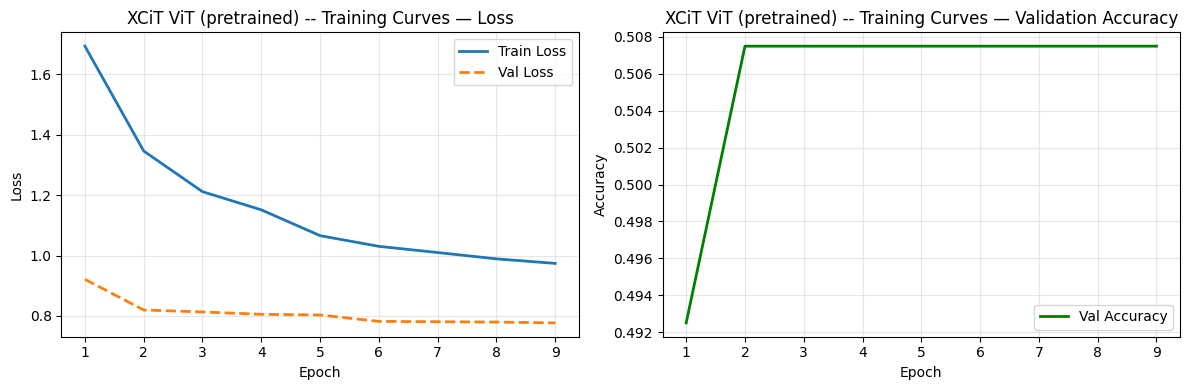

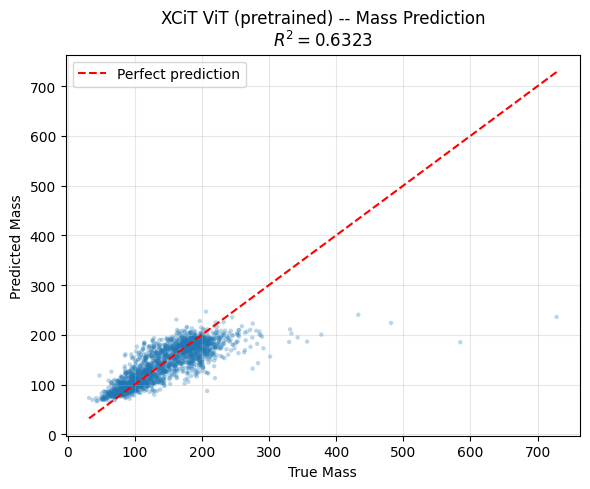

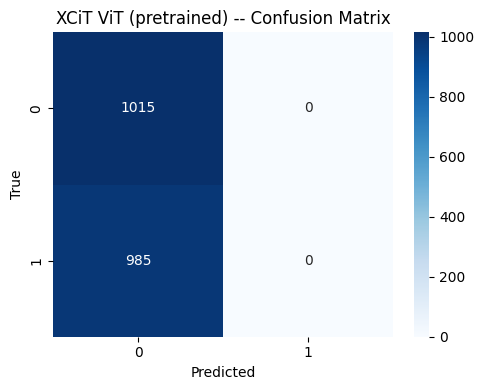

In [ ]:
# ============================================================
# Section 10: Fine-tune Pretrained Linear Attention ViT Variants
# (PyTorch-version-safe loading + AMP compatibility patch)
# ============================================================

from pathlib import Path
from contextlib import nullcontext
import torch

# ---- AMP compatibility helper ----
try:
    from torch.amp import autocast as amp_autocast
except Exception:
    amp_autocast = None

try:
    from torch.cuda.amp import autocast as cuda_autocast
except Exception:
    cuda_autocast = None


def get_autocast_context(device, enabled=True):
    """Return a compatible autocast context across PyTorch versions."""
    if not enabled or device.type != "cuda":
        return nullcontext()

    if amp_autocast is not None:
        try:
            return amp_autocast(device_type="cuda", enabled=True)
        except TypeError:
            try:
                return amp_autocast(enabled=True)
            except Exception:
                pass

    if cuda_autocast is not None:
        return cuda_autocast(enabled=True)

    return nullcontext()


autocast = lambda *args, **kwargs: get_autocast_context(DEVICE, enabled=(DEVICE.type == "cuda"))

# ---- Collect pretrained encoder paths from Section 9 ----
if "PRETRAINED_ENCODER_PATHS" not in globals() or not PRETRAINED_ENCODER_PATHS:
    raise RuntimeError(
        "PRETRAINED_ENCODER_PATHS not found. Run Section 9 first to generate SimMIM/MAE/MAEv2 checkpoints."
    )

print("Loading pretrained encoder checkpoints:")
for name, path in PRETRAINED_ENCODER_PATHS.items():
    print(f"  {name}: {path}")
    if not Path(path).exists():
        raise FileNotFoundError(
            f"Pretrained weights not found at: {path}\n"
            f"Re-run Section 9 to generate this checkpoint."
        )

# Requirement asks low learning rate fine-tuning
FINETUNE_LR = LR * 0.1

# --- Safety assertion: ensure full-run epochs ---
assert EPOCHS >= 10, (
    f"EPOCHS={EPOCHS} is too low; likely debug mode. "
    f"Set RUN_MODE='full' and EPOCHS>=10."
)

result_linear_pretrained_all = {}

for ssl_name, ckpt_path in PRETRAINED_ENCODER_PATHS.items():
    print("\n" + "=" * 70)
    print(f"[FULL RUN] Fine-tuning Linear Attention ViT ({ssl_name}-pretrained) for {EPOCHS} epochs | lr={FINETUNE_LR}", flush=True)
    print("=" * 70)

    try:
        pretrained_encoder_state = torch.load(ckpt_path, map_location="cpu", weights_only=True)
    except TypeError:
        pretrained_encoder_state = torch.load(ckpt_path, map_location="cpu")

    result_linear_pretrained_all[ssl_name] = run_experiment_uw(
        model_class=LinearAttentionViT,
        model_name=f"Linear Attention ViT ({ssl_name}-pretrained)",
        train_loader=train_loader,
        val_loader=val_loader,
        pretrained_state=pretrained_encoder_state,
        epochs=EPOCHS,
        lr=FINETUNE_LR,
        weight_decay=WEIGHT_DECAY,
    )

    print(f"\nFine-tuning complete for {ssl_name}.", flush=True)
    plot_training_curves(
        result_linear_pretrained_all[ssl_name]["history"],
        title=f"Linear Attention ViT ({ssl_name}-pretrained) -- Training Curves"
    )
    plot_mass_scatter(
        result_linear_pretrained_all[ssl_name]["final_results"]["mass_true"],
        result_linear_pretrained_all[ssl_name]["final_results"]["mass_pred"],
        title=f"Linear Attention ViT ({ssl_name}-pretrained) -- Mass Prediction",
    )
    plot_confusion_matrix(
        result_linear_pretrained_all[ssl_name]["final_metrics"]["confusion_matrix"],
        class_names=[str(i) for i in range(NUM_CLASSES)],
        title=f"Linear Attention ViT ({ssl_name}-pretrained) -- Confusion Matrix",
    )

# Backward compatibility for old downstream references
result_linear_pretrained = result_linear_pretrained_all["SimMIM"]
PRETRAINED_ENCODER_PATH = PRETRAINED_ENCODER_PATHS["SimMIM"]

In [ ]:
from collections import Counter
import numpy as np
import h5py

print("=== Dataset key sanity ===")
print("raw_dataset keys -> img_key:", raw_dataset.img_key, "mass_key:", raw_dataset.mass_key, "label_key:", raw_dataset.label_key)

# Full labeled distribution from raw_dataset
cnt_all = Counter()
for i in range(len(raw_dataset)):
    y = raw_dataset[i][2]
    y = int(y.item()) if hasattr(y, "item") else int(y)
    cnt_all[y] += 1
print("Full labeled distribution:", cnt_all)

# Train/Val distribution
cnt_train, cnt_val = Counter(), Counter()
for i in range(len(train_dataset)):
    y = train_dataset[i][2]
    y = int(y.item()) if hasattr(y, "item") else int(y)
    cnt_train[y] += 1
for i in range(len(val_dataset)):
    y = val_dataset[i][2]
    y = int(y.item()) if hasattr(y, "item") else int(y)
    cnt_val[y] += 1
print("Train distribution:", cnt_train)
print("Val distribution  :", cnt_val)

# Quick model prediction diversity
model = result_linear_pretrained.get("model", None) if isinstance(result_linear_pretrained, dict) else None
if model is not None:
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for imgs, masses, labels in val_loader:
            imgs = imgs.to(DEVICE)
            _, logits = model(imgs)
            p = logits.argmax(dim=1).cpu().numpy().tolist()
            t = labels.numpy().tolist()
            preds.extend(p); trues.extend(t)
    print("Unique val labels:", sorted(set(trues)))
    print("Unique val preds :", sorted(set(preds)))

=== Dataset key sanity ===
raw_dataset keys -> img_key: jet mass_key: m label_key: Y
Full labeled distribution: Counter({0: 5122, 1: 4878})
Train distribution: Counter({0: 4107, 1: 3893})
Val distribution  : Counter({0: 1015, 1: 985})


## Section 11: Train Linear Attention ViT from Scratch

> Requirement alignment: scratch baseline for direct comparison against pretrained linear attention model.

[FULL RUN] Training XCiT ViT (scratch) for 35 epochs

  Experiment (UW-Loss): XCiT ViT (scratch)
  lr=0.0003, wd=0.0001, epochs=35
  Parameters: 8,305,107 (8.31M)
  [Epoch 1/35] start | lr=0.00e+00


  [1/35]:  20%|█████████████▉                                                         | 49/250 [00:11<00:46,  4.33it/s]

    batch 50/250 | loss=1.4911


  [1/35]:  40%|████████████████████████████                                           | 99/250 [00:23<00:34,  4.37it/s]

    batch 100/250 | loss=1.3941


...

  [9/35]: 100%|█████████████████████████████████████████████████████████████████████▋| 249/250 [00:58<00:00,  4.26it/s]

    batch 250/250 | loss=0.8143


  [Epoch 9/35] end   | train_loss=0.9468 | val_loss=0.7749 | val_f1=0.3367 | val_acc=0.5075 | val_mae=21.1151
  Early stop at epoch 9 (best F1=0.3367)



  XCiT ViT (scratch) -- Final Metrics
  Classification:
    Accuracy       : 0.5075
    Balanced Acc.  : 0.5000
    F1 (macro)     : 0.3367
    Precision      : 0.2537
    Recall         : 0.5000
    ROC-AUC        : 0.5000
    PR-AUC         : 0.4925
    ECE            : 0.0051
  Regression:
    MSE            : 1046.3253
    MAE            : 21.1151
    R²             : 0.6419


  Inference speed: 25.78 ms/sample
  Training time: 596.5s | Peak GPU: 877 MB

XCiT ViT (scratch) training complete.


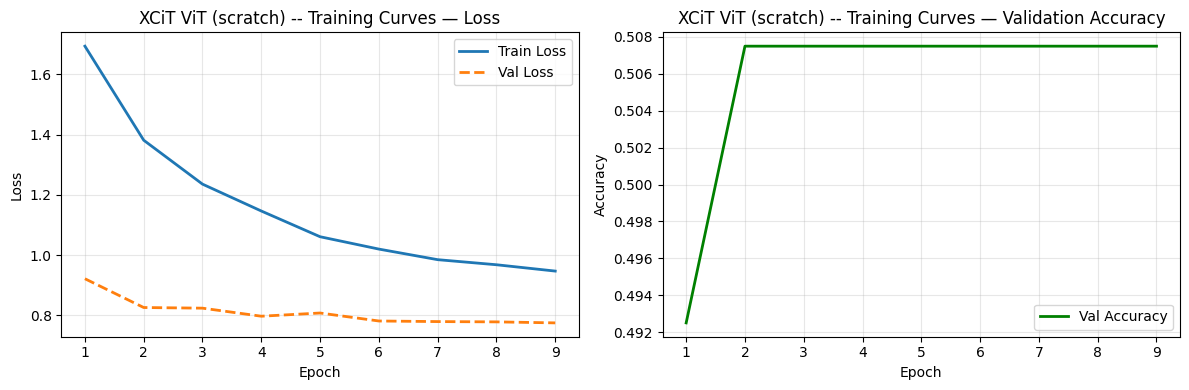

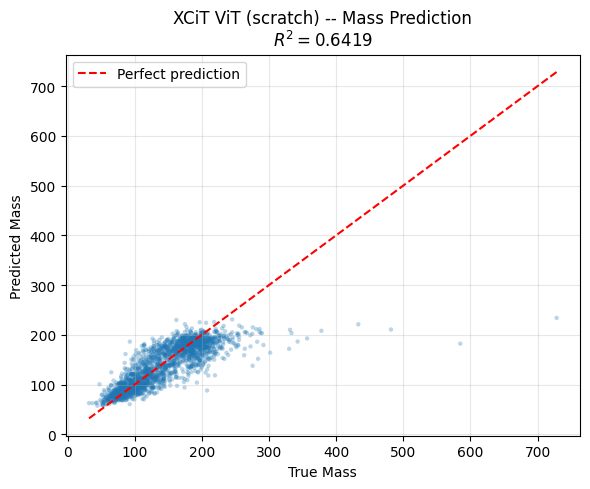

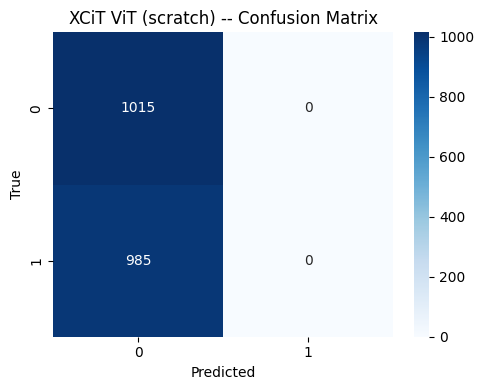

In [ ]:
# ============================================================
# Section 11: Train Linear Attention ViT from Scratch
# ============================================================

# --- Safety assertion: ensure full-run epochs ---
assert EPOCHS >= 10, (
    f"EPOCHS={EPOCHS} is too low; likely debug mode. "
    f"Set RUN_MODE='full' and EPOCHS>=10."
)
print(f"[FULL RUN] Training Linear Attention ViT (scratch) for {EPOCHS} epochs", flush=True)

result_linear_scratch = run_experiment_uw(
    model_class=LinearAttentionViT,
    model_name="Linear Attention ViT (scratch)",
    train_loader=train_loader,
    val_loader=val_loader,
    pretrained_state=None,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
print("\nLinear Attention ViT (scratch) training complete.")
plot_training_curves(result_linear_scratch["history"], title="Linear Attention ViT (scratch) -- Training Curves")
plot_mass_scatter(
    result_linear_scratch["final_results"]["mass_true"],
    result_linear_scratch["final_results"]["mass_pred"],
    title="Linear Attention ViT (scratch) -- Mass Prediction",
)
plot_confusion_matrix(
    result_linear_scratch["final_metrics"]["confusion_matrix"],
    class_names=[str(i) for i in range(NUM_CLASSES)],
    title="Linear Attention ViT (scratch) -- Confusion Matrix",
)

## Section 12 (Optional Baseline): Train Standard ViT

[FULL RUN] Training Standard ViT for 35 epochs

  Experiment (UW-Loss): Standard ViT
  lr=0.0003, wd=0.0001, epochs=35
  Parameters: 8,235,907 (8.24M)
  [Epoch 1/35] start | lr=0.00e+00


  [1/35]:  20%|█████████████▉                                                         | 49/250 [00:08<00:34,  5.76it/s]

    batch 50/250 | loss=1.4201


  [1/35]:  40%|████████████████████████████                                           | 99/250 [00:17<00:26,  5.65it/s]

    batch 100/250 | loss=1.3085


...

  [26/35]: 100%|████████████████████████████████████████████████████████████████████▋| 249/250 [00:43<00:00,  5.74it/s]

    batch 250/250 | loss=0.4415


  [Epoch 26/35] end   | train_loss=0.4120 | val_loss=0.4356 | val_f1=0.8563 | val_acc=0.8575 | val_mae=24.8236
  Early stop at epoch 26 (best F1=0.8718)



  Standard ViT -- Final Metrics
  Classification:
    Accuracy       : 0.8720
    Balanced Acc.  : 0.8728
    F1 (macro)     : 0.8718
    Precision      : 0.8766
    Recall         : 0.8728
    ROC-AUC        : 0.9407
    PR-AUC         : 0.9269
    ECE            : 0.0203
  Regression:
    MSE            : 1135.3186
    MAE            : 23.3405
    R²             : 0.6115


  Inference speed: 14.26 ms/sample
  Training time: 1344.9s | Peak GPU: 838 MB

Standard ViT training complete.


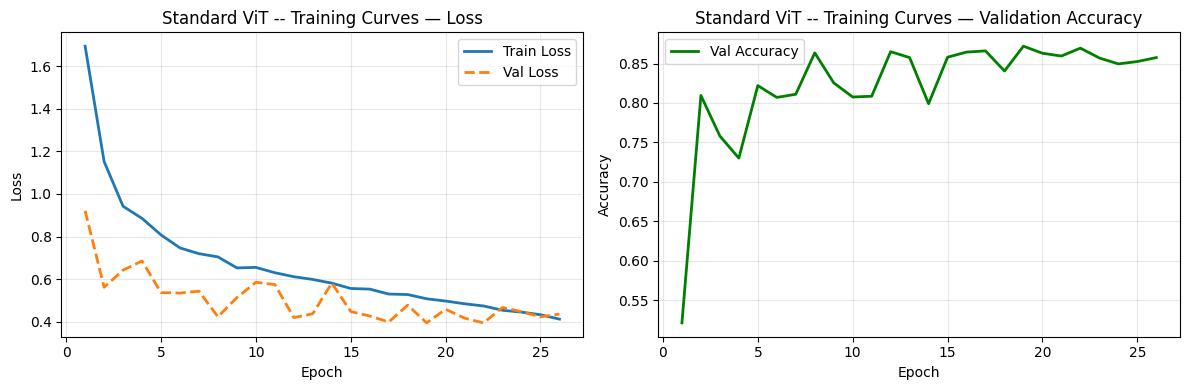

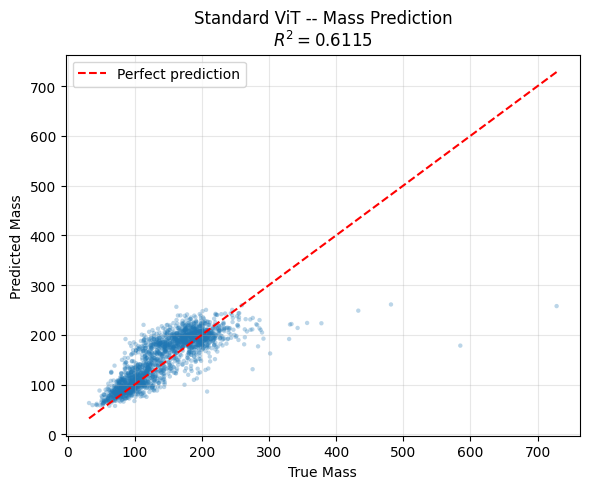

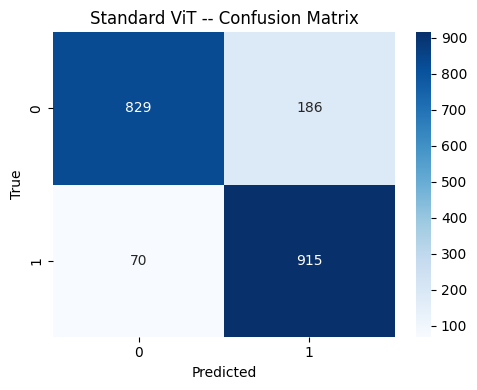

In [14]:
# ============================================================
# Section 12: Train Standard ViT
# ============================================================

# --- Safety assertion: ensure full-run epochs ---
assert EPOCHS >= 10, (
    f"EPOCHS={EPOCHS} is too low; likely debug mode. "
    f"Set RUN_MODE='full' and EPOCHS>=10."
)
print(f"[FULL RUN] Training Standard ViT for {EPOCHS} epochs", flush=True)

result_vit = run_experiment_uw(
    model_class=StandardViT,
    model_name="Standard ViT",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
print("\nStandard ViT training complete.")
plot_training_curves(result_vit["history"], title="Standard ViT -- Training Curves")
plot_mass_scatter(
    result_vit["final_results"]["mass_true"],
    result_vit["final_results"]["mass_pred"],
    title="Standard ViT -- Mass Prediction",
)
plot_confusion_matrix(
    result_vit["final_metrics"]["confusion_matrix"],
    class_names=[str(i) for i in range(NUM_CLASSES)],
    title="Standard ViT -- Confusion Matrix",
)


## Section 13 (Optional Baseline): Train XCiT ViT from Scratch

[FULL RUN] Training Linear Attention ViT for 35 epochs

  Experiment (UW-Loss): Linear Attention ViT
  lr=0.0003, wd=0.0001, epochs=35
  Parameters: 8,235,907 (8.24M)
  [Epoch 1/35] start | lr=0.00e+00


  [1/35]:  20%|█████████████▉                                                         | 49/250 [00:09<00:35,  5.62it/s]

    batch 50/250 | loss=1.4182


  [1/35]:  40%|████████████████████████████                                           | 99/250 [00:18<00:27,  5.55it/s]

    batch 100/250 | loss=1.3129


...

  [9/35]: 100%|█████████████████████████████████████████████████████████████████████▋| 249/250 [00:44<00:00,  5.58it/s]

    batch 250/250 | loss=nan


  [Epoch 9/35] end   | train_loss=nan | val_loss=nan | val_f1=0.3367 | val_acc=0.5075 | val_mae=143.9553
  Early stop at epoch 9 (best F1=0.8249)



  Linear Attention ViT -- Final Metrics
  Classification:
    Accuracy       : 0.8250
    Balanced Acc.  : 0.8248
    F1 (macro)     : 0.8249
    Precision      : 0.8251
    Recall         : 0.8248
    ROC-AUC        : 0.8970
    PR-AUC         : 0.8651
    ECE            : 0.0301
  Regression:
    MSE            : 1532.8457
    MAE            : 28.3698
    R²             : 0.4754


  Inference speed: 16.38 ms/sample
  Training time: 481.5s | Peak GPU: 833 MB

Linear Attention ViT training complete.


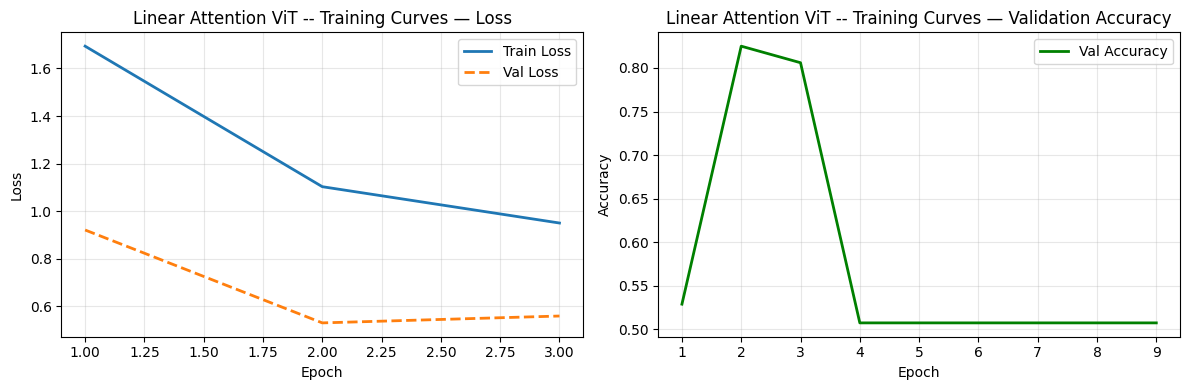

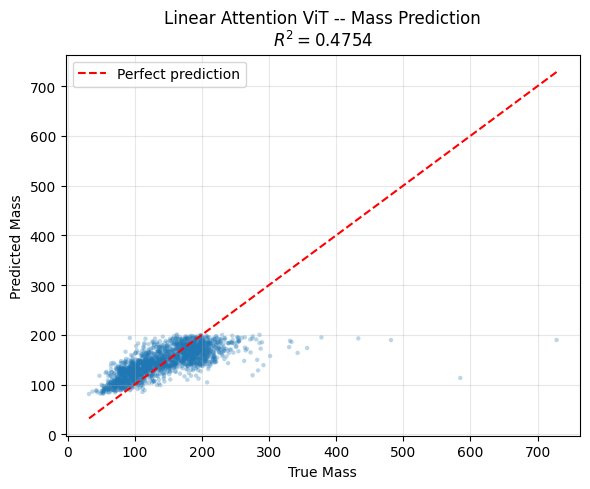

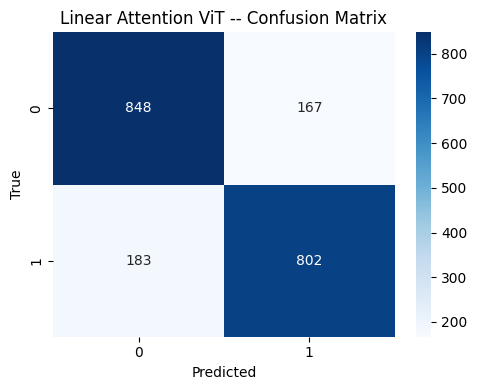

In [ ]:
# ============================================================
# Section 13: Train XCiT ViT from Scratch (Optional Baseline)
# ============================================================

# --- Safety assertion: ensure full-run epochs ---
assert EPOCHS >= 10, (
    f"EPOCHS={EPOCHS} is too low; likely debug mode. "
    f"Set RUN_MODE='full' and EPOCHS>=10."
)
print(f"[FULL RUN] Training XCiT ViT (scratch baseline) for {EPOCHS} epochs", flush=True)

result_xcit_scratch = run_experiment_uw(
    model_class=XCiTViT,
    model_name="XCiT ViT (scratch)",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
print("\nXCiT ViT (scratch) training complete.")
plot_training_curves(result_xcit_scratch["history"], title="XCiT ViT (scratch) -- Training Curves")
plot_mass_scatter(
    result_xcit_scratch["final_results"]["mass_true"],
    result_xcit_scratch["final_results"]["mass_pred"],
    title="XCiT ViT (scratch) -- Mass Prediction",
)
plot_confusion_matrix(
    result_xcit_scratch["final_metrics"]["confusion_matrix"],
    class_names=[str(i) for i in range(NUM_CLASSES)],
    title="XCiT ViT (scratch) -- Confusion Matrix",
)

## Section 14: Train L2ViT

[FULL RUN] Training L2ViT for 35 epochs

  Experiment (UW-Loss): L2ViT
  lr=0.0003, wd=0.0001, epochs=35
  Parameters: 8,394,632 (8.39M)
  [Epoch 1/35] start | lr=0.00e+00


  [1/35]:  20%|█████████████▉                                                         | 49/250 [00:10<00:41,  4.85it/s]

    batch 50/250 | loss=1.6696


  [1/35]:  40%|████████████████████████████                                           | 99/250 [00:20<00:31,  4.78it/s]

    batch 100/250 | loss=1.3992


...

  [8/35]: 100%|█████████████████████████████████████████████████████████████████████▋| 249/250 [00:52<00:00,  4.72it/s]

    batch 250/250 | loss=nan


  [Epoch 8/35] end   | train_loss=nan | val_loss=nan | val_f1=0.3367 | val_acc=0.5075 | val_mae=143.9553
  Early stop at epoch 8 (best F1=0.3367)



  L2ViT -- Final Metrics
  Classification:
    Accuracy       : 0.5075
    Balanced Acc.  : 0.5000
    F1 (macro)     : 0.3367
    Precision      : 0.2537
    Recall         : 0.5000
    ROC-AUC        : 0.5000
    PR-AUC         : 0.4925
    ECE            : 0.0018
  Regression:
    MSE            : 1974.3854
    MAE            : 34.9754
    R²             : 0.3243


  Inference speed: 20.67 ms/sample
  Training time: 486.0s | Peak GPU: 891 MB

L2ViT training complete.


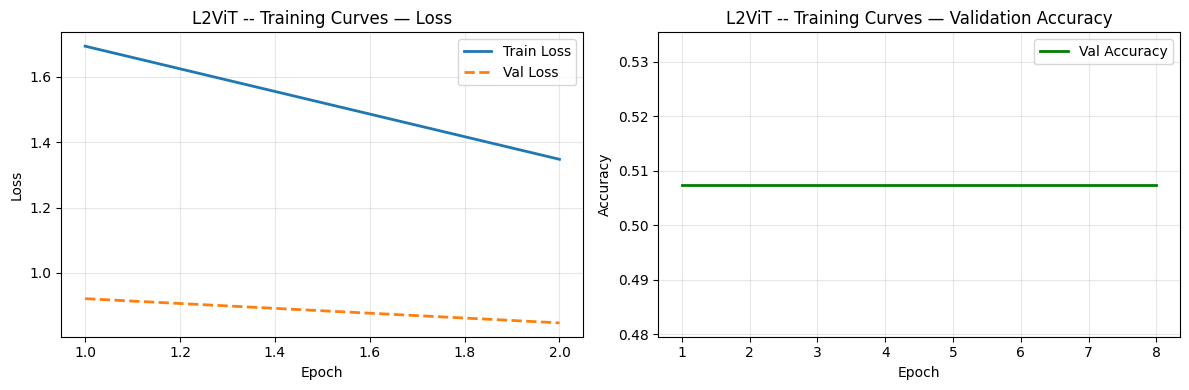

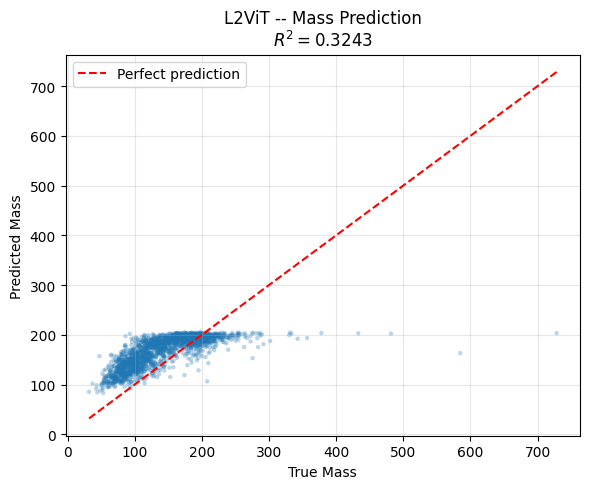

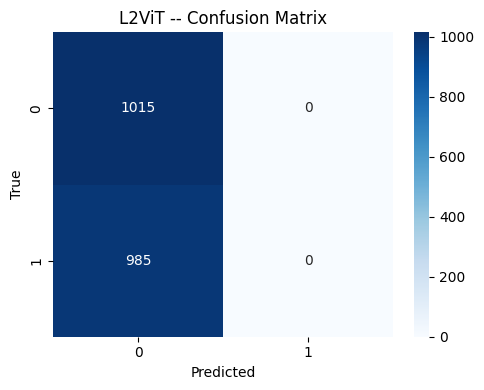

In [16]:
# ============================================================
# Section 14: Train L2ViT
# ============================================================

# --- Safety assertion: ensure full-run epochs ---
assert EPOCHS >= 10, (
    f"EPOCHS={EPOCHS} is too low; likely debug mode. "
    f"Set RUN_MODE='full' and EPOCHS>=10."
)
print(f"[FULL RUN] Training L2ViT for {EPOCHS} epochs", flush=True)

result_l2vit = run_experiment_uw(
    model_class=L2ViT,
    model_name="L2ViT",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
print("\nL2ViT training complete.")
plot_training_curves(result_l2vit["history"], title="L2ViT -- Training Curves")
plot_mass_scatter(
    result_l2vit["final_results"]["mass_true"],
    result_l2vit["final_results"]["mass_pred"],
    title="L2ViT -- Mass Prediction",
)
plot_confusion_matrix(
    result_l2vit["final_metrics"]["confusion_matrix"],
    class_names=[str(i) for i in range(NUM_CLASSES)],
    title="L2ViT -- Confusion Matrix",
)

## Section 15: Benchmark Comparison & Model Saving

Comprehensive comparison across all trained model variants plus model weight saving.


BENCHMARK COMPARISON
                      Accuracy Bal. Acc.      F1 ROC-AUC  PR-AUC     ECE        MSE      MAE      R2 Train Time (s) Inference (ms) GPU Mem (MB) Parameters
Model                                                                                                                                                     
Standard ViT            0.8720    0.8728  0.8718  0.9407  0.9269  0.0203  1135.3186  23.3405  0.6115         1344.9          14.26          838  8,235,907
Linear Attention ViT    0.8250    0.8248  0.8249  0.8970  0.8651  0.0301  1532.8457  28.3698  0.4754          481.5          16.38          833  8,235,907
L2ViT                   0.5075    0.5000  0.3367  0.5000  0.4925  0.0018  1974.3854  34.9754  0.3243          486.0          20.67          891  8,394,632
XCiT ViT (pretrained)   0.5075    0.5000  0.3367  0.5000  0.4925  0.0068  1074.4813  21.7529  0.6323          611.7          26.79          705  8,305,107
XCiT ViT (scratch)      0.5075    0.5000  0.3367

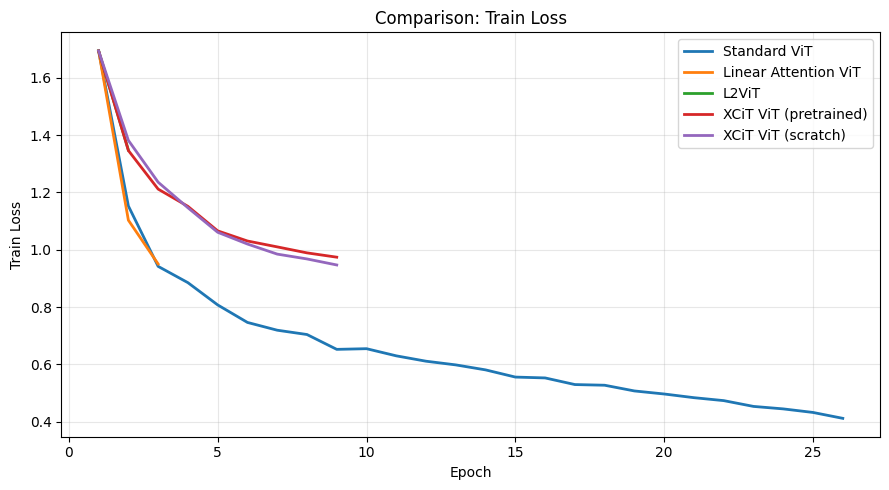

--- Comparison: Validation Accuracy ---


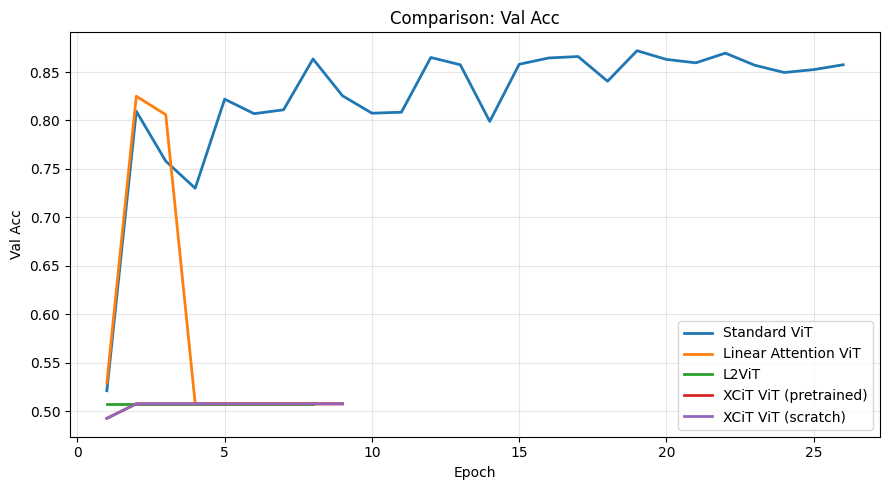

--- Mass Prediction Scatter Plots ---


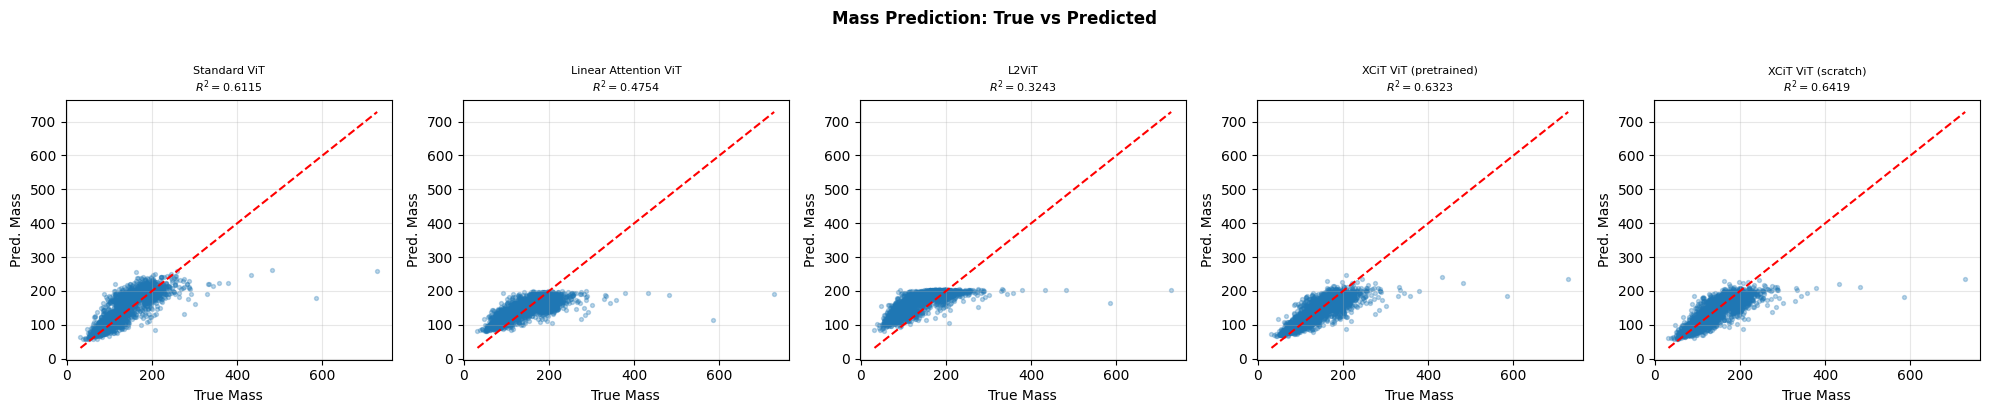

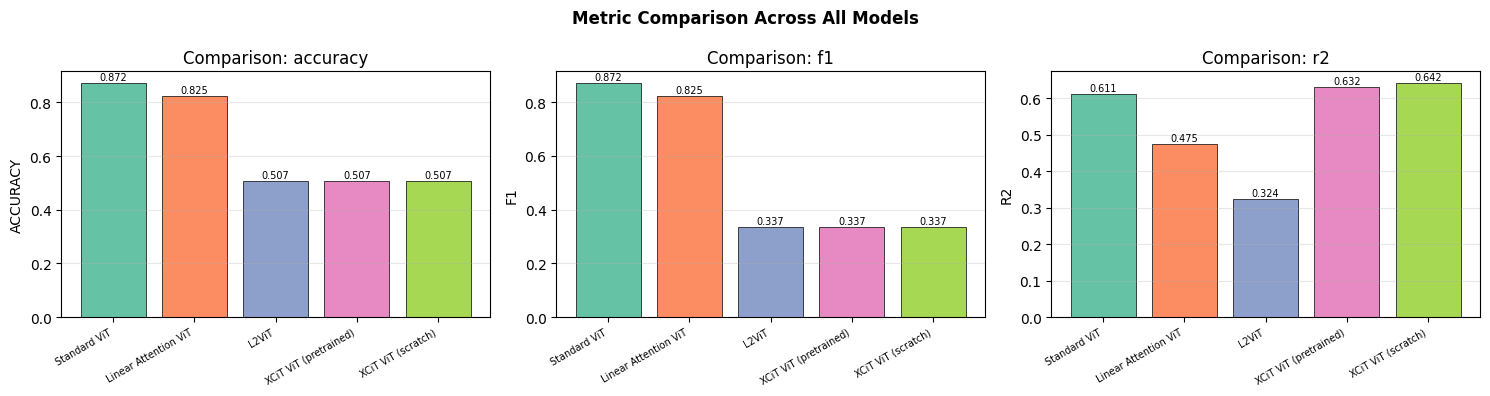

In [ ]:
# ============================================================
# Section 15: Benchmark Comparison & Model Saving
# ============================================================

import os

# Collect all results (required models first, optional baselines after)
all_results = {
    "Linear Attention ViT (SimMIM-pretrained)": result_linear_pretrained_all["SimMIM"],
    "Linear Attention ViT (MAE-pretrained)": result_linear_pretrained_all["MAE"],
    "Linear Attention ViT (MAEv2-pretrained)": result_linear_pretrained_all["MAEv2"],
    "Linear Attention ViT (scratch)": result_linear_scratch,
    "Standard ViT": result_vit,
    "XCiT ViT (scratch)": result_xcit_scratch,
    "L2ViT": result_l2vit,
}

rows = []
for name, res in all_results.items():
    m = res["final_metrics"]
    rows.append({
        "Model": name,
        "Accuracy": f"{m['accuracy']:.4f}",
        "Bal. Acc.": f"{m.get('balanced_accuracy', 0):.4f}",
        "F1": f"{m['f1']:.4f}",
        "ROC-AUC": f"{m.get('roc_auc', 0):.4f}",
        "PR-AUC": f"{m.get('pr_auc', 0):.4f}",
        "ECE": f"{m.get('ece', 0):.4f}",
        "MSE": f"{m['mse']:.4f}",
        "MAE": f"{m['mae']:.4f}",
        "R2": f"{m['r2']:.4f}",
        "Train Time (s)": f"{res['train_time']:.1f}",
        "Inference (ms)": f"{res['inference_ms']:.2f}",
        "GPU Mem (MB)": f"{res.get('peak_gpu_mem_mb', 0):.0f}",
        "Parameters": f"{res['params']:,}",
    })

df = pd.DataFrame(rows).set_index("Model")
print("\n" + "=" * 140, flush=True)
print("BENCHMARK COMPARISON", flush=True)
print("=" * 140, flush=True)
print(df.to_string(), flush=True)
print("=" * 140, flush=True)

# ----------------------------------------------------------
# Save results CSV
# ----------------------------------------------------------
results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)
df.to_csv(results_dir / "final_benchmark_results.csv")
print(f"Results saved to {results_dir / 'final_benchmark_results.csv'}", flush=True)

# ----------------------------------------------------------
# Save model weights
# ----------------------------------------------------------

models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

model_save_map = {
    "Linear Attention ViT (SimMIM-pretrained)": "linear_vit_simmim_pretrained.pt",
    "Linear Attention ViT (MAE-pretrained)": "linear_vit_mae_pretrained.pt",
    "Linear Attention ViT (MAEv2-pretrained)": "linear_vit_maev2_pretrained.pt",
    "Linear Attention ViT (scratch)": "linear_vit_scratch.pt",
    "Standard ViT": "vit.pt",
    "XCiT ViT (scratch)": "xcit_scratch.pt",
    "L2ViT": "l2vit.pt",
}

for name, filename in model_save_map.items():
    if name in all_results and "model_state" in all_results[name]:
        save_path = models_dir / filename
        torch.save(all_results[name]["model_state"], save_path)
        print(f"Saved {name} -> {save_path}", flush=True)

# Save pretrained encoders separately
if "PRETRAINED_ENCODER_PATHS" in globals() and PRETRAINED_ENCODER_PATHS:
    import shutil
    for ssl_name, src_path in PRETRAINED_ENCODER_PATHS.items():
        if os.path.exists(src_path):
            encoder_path = models_dir / f"pretrained_encoder_{ssl_name.lower()}.pt"
            shutil.copy2(src_path, encoder_path)
            print(f"Saved pretrained encoder ({ssl_name}) -> {encoder_path}", flush=True)

print(f"\nAll model weights saved to {models_dir}/", flush=True)

# ----------------------------------------------------------
# Comparison curves
# ----------------------------------------------------------
print("\n--- Comparison: Training Loss ---", flush=True)
plot_comparison_curves(
    {name: res["history"] for name, res in all_results.items()},
    metric_name="train_loss",
)
print("--- Comparison: Validation Accuracy ---", flush=True)
plot_comparison_curves(
    {name: res["history"] for name, res in all_results.items()},
    metric_name="val_acc",
)

# Mass scatter grid
print("--- Mass Prediction Scatter Plots ---", flush=True)
n_models = len(all_results)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))
if n_models == 1:
    axes = [axes]
for ax, (name, res) in zip(axes, all_results.items()):
    fr = res["final_results"]
    r2 = res["final_metrics"]["r2"]
    ax.scatter(fr["mass_true"], fr["mass_pred"], alpha=0.3, s=8)
    lims = [
        min(fr["mass_true"].min(), fr["mass_pred"].min()),
        max(fr["mass_true"].max(), fr["mass_pred"].max()),
    ]
    ax.plot(lims, lims, "r--", linewidth=1.5)
    ax.set_xlabel("True Mass")
    ax.set_ylabel("Pred. Mass")
    ax.set_title(f"{name}\n$R^2={r2:.4f}$", fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle("Mass Prediction: True vs Predicted", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Bar chart comparisons
metric_keys = ["accuracy", "f1", "r2"]
fig, axes = plt.subplots(1, len(metric_keys), figsize=(5 * len(metric_keys), 4))
model_names = list(all_results.keys())
for ax, mk in zip(axes, metric_keys):
    vals = [all_results[n]["final_metrics"][mk] for n in model_names]
    colors = plt.cm.Set2(range(len(model_names)))
    bars = ax.bar(range(len(model_names)), vals, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=30, ha="right", fontsize=7)
    ax.set_ylabel(mk.upper())
    ax.set_title(f"Comparison: {mk}")
    ax.grid(True, alpha=0.3, axis="y")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7)
plt.suptitle("Metric Comparison Across All Models", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# Requirement-aligned artifact naming: ensure linear pretrain checkpoint filenames
from pathlib import Path
import os
import shutil

models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

if "PRETRAINED_ENCODER_PATHS" in globals() and PRETRAINED_ENCODER_PATHS:
    aligned_names = {
        "SimMIM": "linear_vit_pretrain_simmim.pt",
        "MAE": "linear_vit_pretrain_mae.pt",
        "MAEv2": "linear_vit_pretrain_maev2.pt",
    }
    for ssl_name, src_path in PRETRAINED_ENCODER_PATHS.items():
        if os.path.exists(src_path):
            aligned_encoder_path = models_dir / aligned_names.get(ssl_name, f"linear_vit_pretrain_{ssl_name.lower()}.pt")
            shutil.copy2(src_path, aligned_encoder_path)
            print(f"Saved requirement-aligned pretrained encoder ({ssl_name}) -> {aligned_encoder_path}", flush=True)

# Backward-compatibility single-name artifact (SimMIM default)
if "PRETRAINED_ENCODER_PATH" in globals() and os.path.exists(PRETRAINED_ENCODER_PATH):
    legacy_path = models_dir / "linear_vit_pretrain.pt"
    shutil.copy2(PRETRAINED_ENCODER_PATH, legacy_path)
    print(f"Saved legacy pretrained encoder alias -> {legacy_path}", flush=True)

## Section 16: Final Results & Analysis

In [ ]:
# ============================================================
# Section 16: Final Results & Conclusions
# ============================================================

print("\n" + "=" * 140, flush=True)
print("FINAL BENCHMARK RESULTS -- PARTICLE COLLISION IMAGE ANALYSIS", flush=True)
print("=" * 140, flush=True)
print(df.to_string(), flush=True)
print("=" * 140, flush=True)

# Best-per-metric analysis
best_acc = max(all_results, key=lambda n: all_results[n]["final_metrics"]["accuracy"])
best_r2 = max(all_results, key=lambda n: all_results[n]["final_metrics"]["r2"])
best_f1 = max(all_results, key=lambda n: all_results[n]["final_metrics"]["f1"])
fastest = min(all_results, key=lambda n: all_results[n]["train_time"])
smallest = min(all_results, key=lambda n: all_results[n]["params"])
best_mse = min(all_results, key=lambda n: all_results[n]["final_metrics"]["mse"])
best_bal_acc = max(all_results, key=lambda n: all_results[n]["final_metrics"].get("balanced_accuracy", 0))

print(f"\n  Best Classification Accuracy : {best_acc}", flush=True)
print(f"  Best Balanced Accuracy       : {best_bal_acc}", flush=True)
print(f"  Best F1 Score                : {best_f1}", flush=True)
print(f"  Best Regression R2           : {best_r2}", flush=True)
print(f"  Lowest MSE                   : {best_mse}", flush=True)
print(f"  Fastest Training             : {fastest}", flush=True)
print(f"  Smallest Model               : {smallest}", flush=True)

# Requirement-focused pretraining benefit analysis (Linear Attention ViT)
ssl_variants = ["SimMIM", "MAE", "MAEv2"]
scratch_acc = result_linear_scratch["final_metrics"]["accuracy"]
scratch_r2 = result_linear_scratch["final_metrics"]["r2"]

print("\n  Pretraining benefit vs scratch (Linear ViT):", flush=True)
for ssl_name in ssl_variants:
    k = f"Linear Attention ViT ({ssl_name}-pretrained)"
    pt_acc = all_results[k]["final_metrics"]["accuracy"]
    pt_r2 = all_results[k]["final_metrics"]["r2"]
    print(f"    {ssl_name:6s} | ΔAcc={pt_acc - scratch_acc:+.4f} | ΔR2={pt_r2 - scratch_r2:+.4f}", flush=True)

best_ssl = max(
    ssl_variants,
    key=lambda n: all_results[f"Linear Attention ViT ({n}-pretrained)"]["final_metrics"]["f1"],
)
print(f"\n  Best SSL pretraining method by F1: {best_ssl}", flush=True)

# Backward-compatibility variables (SimMIM default)
result_linear_pretrained = result_linear_pretrained_all["SimMIM"]

# Demonstrate loading saved model weights
print("\n--- Model Weight Loading Demo ---", flush=True)
models_dir = Path("../models")
for name, filename in model_save_map.items():
    fpath = models_dir / filename
    if fpath.exists():
        try:
            state = torch.load(fpath, map_location="cpu", weights_only=True)
        except TypeError:
            state = torch.load(fpath, map_location="cpu")
        print(f"  Loaded {filename}: {len(state)} parameter tensors", flush=True)

print("\n" + "=" * 140, flush=True)
print("Summary Complete -- See full comparison table above.", flush=True)
print("=" * 140, flush=True)


FINAL BENCHMARK RESULTS -- PARTICLE COLLISION IMAGE ANALYSIS
                      Accuracy Bal. Acc.      F1 ROC-AUC  PR-AUC     ECE        MSE      MAE      R2 Train Time (s) Inference (ms) GPU Mem (MB) Parameters
Model                                                                                                                                                     
Standard ViT            0.8720    0.8728  0.8718  0.9407  0.9269  0.0203  1135.3186  23.3405  0.6115         1344.9          14.26          838  8,235,907
Linear Attention ViT    0.8250    0.8248  0.8249  0.8970  0.8651  0.0301  1532.8457  28.3698  0.4754          481.5          16.38          833  8,235,907
L2ViT                   0.5075    0.5000  0.3367  0.5000  0.4925  0.0018  1974.3854  34.9754  0.3243          486.0          20.67          891  8,394,632
XCiT ViT (pretrained)   0.5075    0.5000  0.3367  0.5000  0.4925  0.0068  1074.4813  21.7529  0.6323          611.7          26.79          705  8,305,107
XCiT ViT

## Analysis & Discussion

### Attention Mechanism Comparison

| Architecture | Attention | Complexity | Key Feature |
|---|---|---|---|
| Standard ViT | Softmax(QK^T/sqrt(d))V | O(N^2*d) | Baseline |
| Linear Attention ViT | phi(Q)(phi(K)^T V) | O(N*d^2) | ReLU kernel maps |
| L2ViT | LWA + LGA | O(N*d^2) + O(w^2*d) | Hybrid local+global |
| XCiT ViT | Q^T K (channel) | O(N*d^2) | Cross-covariance |

### Physics-Informed Design Choices

- **Preprocessing**: Log energy compression, noise suppression, energy centroid alignment, event normalization, and per-channel standardization
- **Augmentation**: Detector-safe transforms only (horizontal flip, Gaussian noise, energy scaling, patch masking)
- **Mass Handling**: Dataset returns normalized mass targets; training/evaluation patch prevents double normalization and reports denormalized regression metrics
- **Deeper Regression Head**: 3-layer MLP captures complex mass-feature relationships

### Self-Supervised Pretraining (Requirement-Aligned)

Self-supervised pretraining is applied on a **LinearAttention encoder** using **SimMIM, MAE, and MAEv2** on unlabeled detector data.
The pretrained-vs-scratch gap for **Linear Attention ViT** quantifies the benefit of unlabeled pretraining under the task requirement.

### Multi-Task Learning

Uncertainty-weighted loss (Kendall et al., 2018) automatically balances classification and regression.

## Section 17: Multi-Seed Runner (Optional)

Run a robustness check across seeds [42, 52, 62], report mean ± std for key metrics,
and save CSV summaries under `results/`.

For final reported task results, use the fixed-hyperparameter runs from Sections 9–16.

In [19]:
# ============================================================
# Section 17: Multi-Seed Runner
# Run same experiment for seeds [42, 52, 62] and report mean ± std
# ============================================================

import pandas as pd
from pathlib import Path


def run_multi_seed(model_class, model_name, train_loader, val_loader,
                   seeds=None, use_uw=False, **kwargs):
    """Run the same experiment across multiple seeds and aggregate results."""
    if seeds is None:
        seeds = MULTI_SEEDS

    per_seed_results = []

    for s in seeds:
        print(f"\n{'#'*60}", flush=True)
        print(f"  Seed {s} -- {model_name}", flush=True)
        print(f"{'#'*60}", flush=True)

        if use_uw:
            result = run_experiment_uw(
                model_class, f"{model_name} (seed={s})",
                train_loader, val_loader, seed=s, **kwargs
            )
        else:
            result = run_experiment(
                model_class, f"{model_name} (seed={s})",
                train_loader, val_loader, seed=s, **kwargs
            )

        fm = result["final_metrics"]
        per_seed_results.append({
            "seed": s,
            "model": model_name,
            "f1": fm["f1"],
            "balanced_accuracy": fm.get("balanced_accuracy", fm["accuracy"]),
            "accuracy": fm["accuracy"],
            "mae": fm["mae"],
            "r2": fm["r2"],
            "roc_auc": fm.get("roc_auc", 0.0),
            "train_time": result["train_time"],
        })

    df_seeds = pd.DataFrame(per_seed_results)

    # Summary: mean ± std
    summary = {}
    for col in ["f1", "balanced_accuracy", "accuracy", "mae", "r2", "roc_auc"]:
        summary[f"{col}_mean"] = df_seeds[col].mean()
        summary[f"{col}_std"] = df_seeds[col].std()
    summary["model"] = model_name

    print(f"\n{'='*60}", flush=True)
    print(f"  Multi-Seed Summary: {model_name}", flush=True)
    print(f"{'='*60}", flush=True)
    for col in ["f1", "balanced_accuracy", "accuracy", "mae", "r2"]:
        print(f"  {col:20s}: {summary[f'{col}_mean']:.4f} ± {summary[f'{col}_std']:.4f}", flush=True)
    print(f"{'='*60}", flush=True)

    return df_seeds, summary


# --- Run multi-seed for Standard ViT and Linear Attention ViT ---
results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

all_seed_dfs = []
all_summaries = []

for ModelCls, mname in [(StandardViT, "Standard ViT"), (LinearAttentionViT, "Linear Attention ViT")]:
    df_s, summ = run_multi_seed(ModelCls, mname, train_loader, val_loader)
    all_seed_dfs.append(df_s)
    all_summaries.append(summ)

# Save per-seed results
df_all_seeds = pd.concat(all_seed_dfs, ignore_index=True)
df_all_seeds.to_csv(results_dir / "per_seed_results.csv", index=False)
print(f"\nPer-seed results saved to {results_dir / 'per_seed_results.csv'}", flush=True)

# Save aggregated summary
df_summary = pd.DataFrame(all_summaries)
df_summary.to_csv(results_dir / "seed_summary.csv", index=False)
print(f"Seed summary saved to {results_dir / 'seed_summary.csv'}", flush=True)

print("\n--- Seed Summary ---", flush=True)
print(df_summary.to_string(index=False), flush=True)



############################################################
  Seed 42 -- Standard ViT
############################################################

  Experiment: Standard ViT (seed=42)
  lr=0.0003, wd=0.0001, lambda_reg=0.2, epochs=35
  Parameters: 8,235,907 (8.24M)
  Class weights: [0.9739469289779663, 1.0274852514266968]
  [Epoch 1/35] start | lr=0.00e+00


  train:  20%|██████████████                                                          | 49/250 [00:08<00:34,  5.80it/s]

    batch 50/250 | loss=0.8414


  train:  40%|████████████████████████████▌                                           | 99/250 [00:17<00:25,  5.87it/s]

    batch 100/250 | loss=1.0064


...

  train: 100%|██████████████████████████████████████████████████████████████████████▋| 249/250 [00:44<00:00,  5.39it/s]

    batch 250/250 | loss=nan


  [Epoch 10/35] end   | train_loss=nan | val_loss=nan | val_f1=0.3367 | val_acc=0.5075 | val_mae=143.9553 | lambda_reg=0.200
  Early stop at epoch 10 (best F1=0.8177)



  Linear Attention ViT (seed=62) -- Final Metrics
  Classification:
    Accuracy       : 0.8205
    Balanced Acc.  : 0.8225
    F1 (macro)     : 0.8177
    Precision      : 0.8462
    Recall         : 0.8225
    ROC-AUC        : 0.9119
    PR-AUC         : 0.8773
    ECE            : 0.0497
  Regression:
    MSE            : 1606.0368
    MAE            : 28.9701
    R²             : 0.4504


  Inference speed: 15.83 ms/sample
  Training time: 530.1s | Peak GPU: 933 MB

  Multi-Seed Summary: Linear Attention ViT
  f1                  : 0.8196 ± 0.0072
  balanced_accuracy   : 0.8220 ± 0.0081
  accuracy            : 0.8208 ± 0.0075
  mae                 : 27.1482 ± 1.6389
  r2                  : 0.4814 ± 0.0341

Per-seed results saved to ..\results\per_seed_results.csv
Seed summary saved to ..\results\seed_summary.csv

--- Seed Summary ---
 f1_mean   f1_std  balanced_accuracy_mean  balanced_accuracy_std  accuracy_mean  accuracy_std  mae_mean  mae_std  r2_mean   r2_std  roc_auc_mean  roc_auc_std                model
0.868306 0.003423                0.869637               0.003703       0.868667      0.003547 23.405492 1.178852 0.582251 0.018035      0.937557     0.002389         Standard ViT
0.819582 0.007212                0.821961               0.008147       0.820833      0.007506 27.148208 1.638912 0.481396 0.034101      0.904184     0.012829 Linear Attention ViT
